In [1]:
!pip install sastrawi
!pip install gensim
!pip uninstall -y fasttext
!pip install fasttext-wheel

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 5.7 MB/s eta 0:00:0000:01
Found existing installation: fasttext 0.9.3
Uninstalling fasttext-0.9.3:
  Successfully uninstalled fasttext-0.9.3
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.6/4.6 MB 48.6 MB/s eta 0:00:00a 0:00:01


In [2]:
import pandas as pd
import numpy as np
import re
import string
import matplotlib.pyplot as plt
import seaborn as sns
import csv
import requests
import xgboost as xgb
import torch
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from transformers import (
    AutoTokenizer, 
    AutoModelForSequenceClassification, 
    TrainingArguments, 
    Trainer,
    TrainerCallback
)
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from io import StringIO
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.naive_bayes import BernoulliNB
from sklearn.metrics import accuracy_score, precision_score
from sklearn.feature_extraction.text import TfidfVectorizer
from nltk.tokenize import word_tokenize  # Tokenisasi teks
from nltk.corpus import stopwords  # Daftar kata-kata berhenti dalam teks
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory  # Stemming (penghilangan imbuhan kata) dalam bahasa Indonesia
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory  # Menghapus kata-kata berhenti dalam bahasa Indonesia
from wordcloud import WordCloud  # Membuat visualisasi berbentuk awan kata (word cloud) dari teks
sns.set()
seed = 42
np.random.seed(seed)

2026-03-02 02:07:16.907664: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1772417237.078728      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772417237.125347      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1772417237.535848      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772417237.535881      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772417237.535884      55 computation_placer.cc:177] computation placer alr

# Function Helper

In [4]:
def plot_frequency_data_kualitatif(df, feature, title, kind="bar", top_10=False, tail=False):
  if top_10:
    if tail:
      plot_data = df[feature].value_counts().tail(10)
      colors = ['blue' if (x == plot_data.min()) else 'lightgray' for x in plot_data]
    else:
      plot_data = df[feature].value_counts().head(10)
      colors = ['blue' if (x == plot_data.max()) else 'lightgray' for x in plot_data]
  else:
    plot_data = df[feature].value_counts()
    colors = ['blue' if (x == plot_data.max()) else 'lightgray' for x in plot_data]

  ax = plot_data.plot.bar(figsize=(15, 5), color=colors) if kind == "bar" else plot_data.plot.barh(figsize=(15, 5), color=colors)
  ax.set_title(title, fontsize=14)
  ax.set_xlabel(None)
  ax.set_ylabel(None)

  for container in ax.containers:
      ax.bar_label(container)

  plt.show()

In [5]:
def prep_word_cloud(polarity):
    result = clean_df[clean_df['polarity'] == polarity]
    result = result[['text_final', 'score', 'polarity','text_stopword']]
    result = result.sort_values(by='score', ascending=False)
    result = result.reset_index(drop=True)
    result.index += 1
    return result

In [6]:
def plot_word_cloud(reviews, title):
    list_words = ''
    
    for review in reviews:
        for word in review:
            list_words += ' ' + (word)
    
    wordcloud = WordCloud(width=600, height=400, background_color='white', min_font_size=10).generate(list_words)
    
    fig, ax = plt.subplots(figsize=(8, 6))
    ax.set_title(f'Word Cloud of {title} Review', fontsize=18)
    ax.grid(False)
    ax.imshow((wordcloud))
    fig.tight_layout(pad=0)
    ax.axis('off')
    plt.show()

In [7]:
df = pd.read_csv("/kaggle/input/datasets/hendrimardani/gojek-sentiment-analysis-text/gojek_sentiment_analysis.csv")
df.head()

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
0,be36a33f-83e9-4766-8a94-1100a46adc83,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,mantap,5,0,5.48.2,2026-02-21 14:03:55,NaN,NaN,5.48.2
1,b53f7b4e-f601-42e3-9f48-541b51bd5f57,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,dari th 2019 sampai 2026 aku masih berlanggana...,5,0,NaN,2026-02-21 13:47:12,NaN,NaN,NaN
2,1ff3bcd5-2a5e-47f6-bd01-8f29944eb87f,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,top,5,0,5.50.1,2026-02-21 13:26:55,NaN,NaN,5.50.1
3,c9d6374b-db65-4d7f-a63d-33d258f7fa5d,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,sangat buruk 🤮,1,0,NaN,2026-02-21 13:02:38,NaN,NaN,NaN
4,6f8a13ac-968d-4209-b302-2084ce164084,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,nice,5,0,5.49.1,2026-02-21 12:58:13,NaN,NaN,5.49.1


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500000 entries, 0 to 499999
Data columns (total 11 columns):
 #   Column                Non-Null Count   Dtype 
---  ------                --------------   ----- 
 0   reviewId              500000 non-null  object
 1   userName              500000 non-null  object
 2   userImage             500000 non-null  object
 3   content               499994 non-null  object
 4   score                 500000 non-null  int64 
 5   thumbsUpCount         500000 non-null  int64 
 6   reviewCreatedVersion  388252 non-null  object
 7   at                    500000 non-null  object
 8   replyContent          136777 non-null  object
 9   repliedAt             136777 non-null  object
 10  appVersion            388252 non-null  object
dtypes: int64(2), object(9)
memory usage: 42.0+ MB


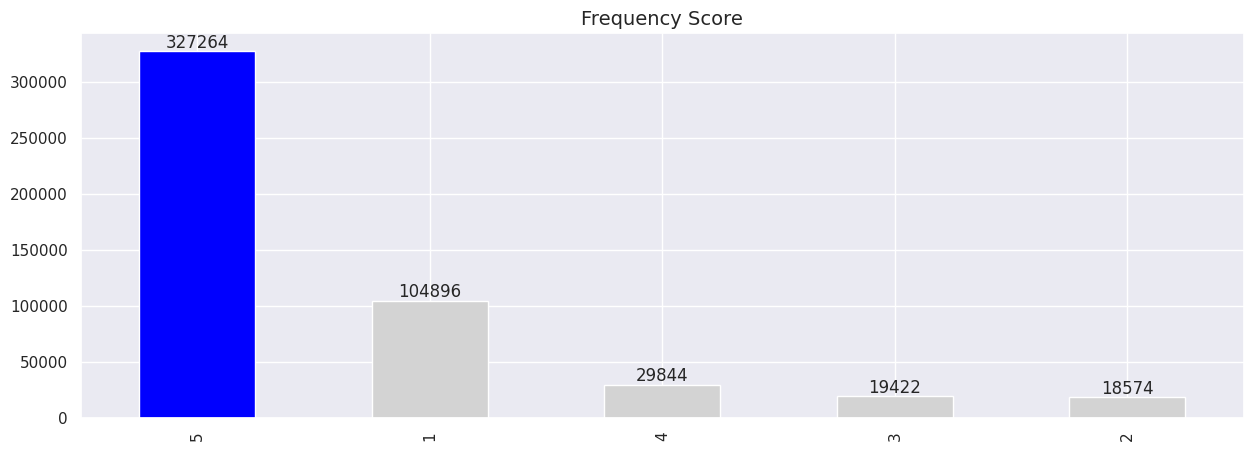

In [9]:
plot_frequency_data_kualitatif(df, "score", "Frequency Score")

In [10]:
df = df[["content", "score"]]
df.head()

,content,score
0,mantap,5
1,dari th 2019 sampai 2026 aku masih berlanggana...,5
2,top,5
3,sangat buruk 🤮,1
4,nice,5


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500000 entries, 0 to 499999
Data columns (total 2 columns):
 #   Column   Non-Null Count   Dtype 
---  ------   --------------   ----- 
 0   content  499994 non-null  object
 1   score    500000 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 7.6+ MB


In [12]:
clean_df = df.dropna()
clean_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 499994 entries, 0 to 499999
Data columns (total 2 columns):
 #   Column   Non-Null Count   Dtype 
---  ------   --------------   ----- 
 0   content  499994 non-null  object
 1   score    499994 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 11.4+ MB


In [13]:
print(f"Duplicate Feature : {clean_df.duplicated().sum().tolist()}")

Duplicate Feature : 188748


In [14]:
clean_df = clean_df.drop_duplicates()
clean_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 311246 entries, 0 to 499999
Data columns (total 2 columns):
 #   Column   Non-Null Count   Dtype 
---  ------   --------------   ----- 
 0   content  311246 non-null  object
 1   score    311246 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 7.1+ MB


# Preprocessing

In [15]:
def cleaningText(text):
    text = re.sub(r'@[A-Za-z0-9]+', '', text) # remove mentions
    text = re.sub(r'#[A-Za-z0-9]+', '', text) # remove hashtag
    text = re.sub(r'RT[\s]', '', text) # remove RT
    text = re.sub(r"http\S+", '', text) # remove link
    text = re.sub(r'[0-9]+', '', text) # remove numbers
    text = re.sub(r'[^\w\s]', '', text) # remove numbers
    text = text.replace('\n', ' ') # replace new line into space
    text = text.translate(str.maketrans('', '', string.punctuation)) # remove all punctuations
    text = text.strip(' ') # remove characters space from both left and right text
    return text

def casefoldingText(text): # Converting all the characters in a text into lower case
    text = text.lower()
    return text

def tokenizingText(text): # Tokenizing or splitting a string, text into a list of tokens
    text = word_tokenize(text)
    return text

def filteringText(text): # Remove stopwors in a text
    listStopwords = set(stopwords.words('indonesian'))
    listStopwords1 = set(stopwords.words('english'))
    listStopwords.update(listStopwords1)
    listStopwords.update(['iya','yaa','gak','nya','na','sih','ku',"di","ga","ya","gaa","loh","kah","woi","woii","woy"])
    filtered = []
    for txt in text:
        if txt not in listStopwords:
            filtered.append(txt)
    text = filtered
    return text

def stemmingText(text): # Reducing a word to its word stem that affixes to suffixes and prefixes or to the roots of words
    # Membuat objek stemmer
    factory = StemmerFactory()
    stemmer = factory.create_stemmer()

    # Memecah teks menjadi daftar kata
    words = text.split()

    # Menerapkan stemming pada setiap kata dalam daftar
    stemmed_words = [stemmer.stem(word) for word in words]

    # Menggabungkan kata-kata yang telah distem
    stemmed_text = ' '.join(stemmed_words)

    return stemmed_text

def toSentence(list_words): # Convert list of words into sentence
    sentence = ' '.join(word for word in list_words)
    return sentence

In [16]:
slangwords = {
    "7an": "tujuan",
    "@": "di",
    "ababil": "abg labil",
    "abis": "habis",
    "acc": "accord",
    "ad": "ada",
    "adlah": "adalah",
    "adlh": "adalah",
    "adoh": "aduh",
    "afaik": "as far as i know",
    "aha": "tertawa",
    "ahaha": "haha",
    "ahokncc": "ahok",
    "aing": "saya",
    "aj": "saja",
    "aja": "saja",
    "ajep-ajep": "dunia gemerlap",
    "ajj": "saja",
    "ak": "saya",
    "aka": "dikenal juga sebagai",
    "akika": "aku",
    "akhirx": "akhirnya",
    "akkoh": "aku",
    "akko": "aku",
    "akku": "aku",
    "akuwh": "aku",
    "akyu": "aku",
    "alay": "norak",
    "aljasa": "asal jadi saja",
    "alow": "halo",
    "ama": "sama",
    "ambl": "ambil",
    "ambilin": "ambilkan",
    "ambyar": "hancur berantakan",
    "ancur": "hancur",
    "anjay": "anjing (ungkapan kagum atau terkejut)",
    "anjir": "anjing",
    "anjrit": "anjing",
    "ank": "anak",
    "anter": "antar",
    "ap": "apa",
    "ap2": "apa-apa",
    "apaan": "apa",
    "apasih": "apa sih",
    "ape": "apa",
    "apes": "sial",
    "aplot": "unggah",
    "aps": "apa",
    "apva": "apa",
    "aq": "saya",
    "aqu": "aku",
    "aquwh": "aku",
    "asap": "sesegera mungkin",
    "asbun": "asal bunyi",
    "aseek": "asyik",
    "aseekk": "asyik",
    "asek": "asyik",
    "aseknya": "asyiknya",
    "asekk": "asyik",
    "asem": "asam",
    "asoy": "asyik",
    "aspal": "asli tetapi palsu",
    "astrojim": "astagfirullahaladzim",
    "astul": "asal tulis",
    "ath": "kalau begitu",
    "ato": "atau",
    "atuh": "kalau begitu",
    "au ah": "tidak mau tahu",
    "ava": "avatar",
    "awak": "saya",
    "aws": "awas",
    "ay": "sayang",
    "ayang": "sayang",
    "ayank": "sayang",
    "ayok": "ayo",
    "b4": "sebelum",
    "bacot": "banyak bicara",
    "bakalan": "akan",
    "bales": "balas",
    "bandes": "bantuan desa",
    "bangdes": "pembangunan desa",
    "bangedh": "banget",
    "bangkotan": "tua",
    "banpol": "bantuan polisi",
    "banpres": "bantuan presiden",
    "banpur": "bantuan tempur",
    "bansarkas": "bantuan sarana kesehatan",
    "bapack": "bapak",
    "baper": "bawa perasaan",
    "bapuk": "jelek",
    "basbang": "basi",
    "bazis": "badan amal, zakat, infak, dan sedekah",
    "bcanda": "bercanda",
    "bcoz": "karena",
    "bdg": "bandung",
    "beb": "sayang",
    "begajulan": "nakal",
    "bejibun": "banyak",
    "beliin": "belikan",
    "belom": "belum",
    "bencong": "banci",
    "bener": "benar",
    "bengek": "tertawa terbahak-bahak",
    "bentar": "sebentar",
    "ber2": "berdua",
    "ber3": "bertiga",
    "berdikari": "berdiri di atas kaki sendiri",
    "beresin": "membereskan",
    "bestie": "teman baik",
    "bet": "banget",
    "bete": "bosan",
    "beti": "beda tipis",
    "beud": "banget",
    "beut": "banget",
    "bg": "abang",
    "bgd": "banget",
    "bgmn": "bagaimana",
    "bgs": "bagus",
    "bgt": "banget",
    "bgtt": "banget",
    "bgttt": "banget",
    "bhubu": "tidur",
    "bijimane": "bagaimana",
    "bimbuluh": "bimbingan dan penyuluhan",
    "bintal": "bimbingan mental",
    "bisi": "kalau-kalau",
    "bjir": "terkejut",
    "bkl": "akan",
    "bkn": "bukan",
    "bknnya": "bukannya",
    "bl": "beli",
    "blegug": "bodoh",
    "blg": "bilang",
    "blh": "boleh",
    "blm": "belum",
    "bln": "bulan",
    "bls": "balas",
    "blum": "belum",
    "bnci": "benci",
    "bnchi": "benci",
    "bngung": "bingung",
    "bnran": "yang benar",
    "bnyk": "banyak",
    "bocil": "anak kecil",
    "bodor": "lucu",
    "bohay": "badan aduhai",
    "bokap": "ayah",
    "bokep": "porno",
    "boker": "buang air besar",
    "bokin": "pacar",
    "bokis": "bohong",
    "bole": "boleh",
    "boljug": "boleh juga",
    "bolot": "bodoh",
    "bonek": "bocah nekat",
    "bonyok": "ayah ibu",
    "boyeh": "boleh",
    "bpk": "bapak",
    "br": "baru",
    "brb": "segera kembali",
    "brg": "bareng",
    "brngkt": "berangkat",
    "bro": "saudara laki-laki",
    "brp": "berapa",
    "bru": "baru",
    "brur": "saudara laki-laki",
    "bs": "bisa",
    "bsa": "bisa",
    "bsen": "bosan",
    "bsk": "besok",
    "bt": "buat",
    "btw": "ngomong-ngomong",
    "bu_bu": "tidur",
    "buangbuang": "buang",
    "buaya": "tidak setia",
    "bubarin": "bubarkan",
    "bubbu": "tidur",
    "buber": "buka bersama",
    "bubu": "tidur",
    "bucin": "budak cinta",
    "bujubune": "luar biasa",
    "bumil": "ibu hamil",
    "bund": "bunda",
    "buser": "buru sergap",
    "bw": "bawa",
    "bwhn": "bawahan",
    "bwt": "buat",
    "byar": "bayar",
    "byk": "banyak",
    "byr": "bayar",
    "byrin": "bayarkan",
    "c8": "chat",
    "cabal": "sabar",
    "cabut": "pergi",
    "cadas": "keren",
    "caem": "cakep",
    "calo": "makelar",
    "cama-cama": "sama-sama",
    "can": "belum",
    "cangcut": "celana dalam",
    "capcus": "pergi",
    "cape": "capek",
    "caper": "cari perhatian",
    "caur": "jelek",
    "cb": "coba",
    "ce": "cewek",
    "cecan": "cewek cantik",
    "cegil": "cewek gila",
    "cekak": "tidak ada uang",
    "cekal": "cegah tangkal",
    "cekidot": "coba lihat",
    "cemen": "penakut",
    "cemplungin": "cemplungkan",
    "cengengesan": "tertawa",
    "ceper": "pendek",
    "cepet": "cepat",
    "cepu": "tukang mengadu",
    "ceu": "kakak perempuan",
    "cew": "cewek",
    "cewe": "cewek",
    "chuaks": "sindiran",
    "chuyunk": "sayang",
    "cibuk": "sibuk",
    "cimeng": "ganja",
    "cin": "cinta",
    "cipika cipiki": "cium pipi kanan cium pipi kiri",
    "ciye": "cie",
    "ciyh": "sih",
    "ckck": "ck",
    "ckepp": "cakep",
    "ckp": "cakep",
    "clbk": "cinta lama bersemi kembali",
    "cmiiw": "correct me if i'm wrong",
    "cmpr": "campur",
    "cmpur": "campur",
    "cnenk": "senang",
    "cod": "bayar ditempat",
    "cogan": "cowok ganteng",
    "cogil": "cowok gila",
    "cong": "banci",
    "congor": "mulut",
    "conlok": "cinta lokasi",
    "cow": "cowok",
    "cowwyy": "maaf",
    "coz": "karena",
    "cp": "siapa",
    "cpa": "siapa",
    "cpe": "capek",
    "cppe": "capek",
    "cr": "sumber",
    "cringe": "menggelikan",
    "cuan": "keuntungan",
    "cucok": "cocok",
    "cuex": "cuek",
    "cumi": "Cuma miscall",
    "cups": "culun",
    "curanmor": "pencurian kendaraan bermotor",
    "curcol": "curahan hati colongan",
    "cwek": "cewek",
    "cyin": "cinta",
    "d": "di",
    "dah": "deh",
    "dapet": "dapat",
    "dasdes": "cepat",
    "de": "adik",
    "dek": "adik",
    "demen": "suka",
    "deyh": "deh",
    "dgn": "dengan",
    "diancurin": "dihancurkan",
    "dimaafin": "dimaafkan",
    "dimintak": "diminta",
    "disono": "di sana",
    "dket": "dekat",
    "dkk": "dan kawan-kawan",
    "dll": "dan lain-lain",
    "dlu": "dulu",
    "dngn": "dengan",
    "dodol": "bodoh",
    "doku": "uang",
    "dongs": "dong",
    "dpt": "dapat",
    "dri": "dari",
    "drmn": "darimana",
    "drtd": "dari tadi",
    "dst": "dan seterusnya",
    "dtg": "datang",
    "duh": "aduh",
    "duren": "durian",
    "ed": "edisi",
    "effort": "usaha",
    "egp": "emang gue pikirin",
    "eke": "aku",
    "elu": "kamu",
    "emangnya": "memangnya",
    "emng": "memang",
    "endak": "tidak",
    "enggak": "tidak",
    "envy": "iri",
    "ex": "mantan",
    "faktakta": "fakta",
    "fax": "facsimile",
    "fifo": "first in first out",
    "flexing": "pamer",
    "folbek": "follow back",
    "fomo": "takut ketinggalan tren",
    "fyi": "sebagai informasi",
    "fyp": "masuk beranda",
    "gaada": "tidak ada uang",
    "gabut": "gaji buta atau tidak ada kerjaan",
    "gag": "tidak",
    "gaje": "tidak jelas",
    "gak papa": "tidak apa-apa",
    "gamon": "gagal move on",
    "gan": "juragan",
    "gantengsaya": "ganteng",
    "gaptek": "gagap teknologi",
    "garing": "tidak lucu",
    "gatek": "gagap teknologi",
    "gawe": "kerja",
    "gbs": "tidak bisa",
    "gebetan": "orang yang disuka",
    "geje": "tidak jelas",
    "gemoy": "menggemaskan",
    "gepeng": "gelandangan dan pengemis",
    "gercep": "gerak cepat",
    "ghiy": "lagi",
    "gile": "gila",
    "gils": "gila",
    "gimana": "bagaimana",
    "gino": "gigi nongol",
    "githu": "gitu",
    "gj": "tidak jelas",
    "gmana": "bagaimana",
    "gn": "begini",
    "goblok": "bodoh",
    "gokil": "gila",
    "golput": "golongan putih",
    "gombal": "suka merayu",
    "gowes": "mengayuh sepeda",
    "gpl": "tidak pakai lama",
    "gpny": "tidak punya",
    "gpp": "tidak apa-apa",
    "gr": "gede rasa",
    "greenflag": "tanda baik",
    "gretong": "gratis",
    "gretongan": "gratisan",
    "gt": "begitu",
    "gtau": "tidak tahu",
    "gtw": "tidak tahu",
    "gua": "saya",
    "gue": "saya",
    "guoblok": "goblok",
    "gw": "saya",
    "guys": "teman-teman",
    "gws": "cepat sembuh",
    "ha": "tertawa",
    "hadeh": "aduh",
    "haghaghag": "tertawa",
    "haha": "tertawa",
    "hakhak": "tertawa",
    "hallow": "halo",
    "handak": "bahan peledak",
    "hankam": "pertahanan dan keamanan",
    "hansip": "pertahanan sipil",
    "happy": "bahagia",
    "hardcore": "keras",
    "healing": "liburan",
    "hedon": "boros",
    "hehe": "he",
    "hellow": "halo",
    "helo": "halo",
    "helow": "halo",
    "heters": "pembenci",
    "hey": "hai",
    "hi": "hai",
    "hlm": "halaman",
    "hlng": "hilang",
    "hny": "hanya",
    "hnya": "hanya",
    "hoax": "isu bohong",
    "houm": "rumah",
    "hr": "hari",
    "hrs": "harus",
    "hrus": "harus",
    "hts": "hubungan tanpa status",
    "hubad": "hubungan angkatan darat",
    "hubdar": "perhubungan darat",
    "hubla": "perhubungan laut",
    "huft": "mengeluh",
    "huff": "mengeluh",
    "hum": "rumah",
    "humas": "hubungan masyarakat",
    "humz": "rumah",
    "idk": "saya tidak tahu",
    "ikon": "lambang",
    "ilang": "hilang",
    "ilfeel": "tidak suka",
    "ilfil": "tidak suka",
    "imba": "jago sekali",
    "imho": "in my humble opinion",
    "imoet": "imut",
    "imoetz": "imut",
    "indo": "indonesia",
    "info": "informasi",
    "insecure": "tidak percaya diri",
    "isengin": "bercanda",
    "ista": "nista",
    "istaa": "nista",
    "item": "hitam",
    "itung": "hitung",
    "itungan": "hitungan",
    "iyala": "iya lah",
    "iye": "iya",
    "iyo": "iya",
    "ja": "saja",
    "jablay": "jarang dibelai",
    "jadiin": "jadi",
    "jadul": "jaman dulu",
    "jaim": "jaga image",
    "jamet": "kampungan",
    "jancuk": "anjing",
    "japri": "jalur pribadi",
    "jastip": "jasa titip",
    "jayus": "tidak lucu",
    "jd": "jadi",
    "jdi": "jadi",
    "jdikan": "jadikan",
    "jem": "jam",
    "jentelmen": "berani",
    "jg": "juga",
    "jga": "juga",
    "jgn": "jangan",
    "jgnkan": "jangankan",
    "jijay": "jijik",
    "jir": "anjing",
    "jkt": "jakarta",
    "jln": "jalan",
    "jnj": "janji",
    "jomblo": "tidak punya pacar",
    "jomo": "senang tertinggal tren",
    "jth": "jatuh",
    "jubir": "juru bicara",
    "julid": "iri dengki atau nyinyir",
    "jurdil": "jujur adil",
    "jutek": "galak",
    "jwb": "jawab",
    "k": "ke",
    "ka": "kakak",
    "kab": "kabupaten",
    "kabag": "kepala bagian",
    "kabor": "kabur",
    "kacian": "kasihan",
    "kacrut": "kacau",
    "kadit": "kepala direktorat",
    "kadiv": "kepala divisi",
    "kaga": "tidak",
    "kagak": "tidak",
    "kaka": "kakak",
    "kalo": "kalau",
    "kampret": "sialan",
    "kamtib": "keamanan dan ketertiban",
    "kamtibmas": "keamanan dan ketertiban masyarakat",
    "kamuwh": "kamu",
    "kamuh": "kamu",
    "kamyu": "kamu",
    "kane": "enak",
    "kanwil": "kantor wilayah",
    "kapt": "kapten",
    "karna": "karena",
    "kasat": "kepala satuan",
    "kasubbag": "kepala subbagian",
    "kasubbid": "kepala subbidang",
    "katrok": "kampungan",
    "kau": "kamu",
    "kayanya": "kayaknya",
    "kbar": "kabar",
    "kbr": "kabar",
    "kcian": "kasihan",
    "kdu": "harus",
    "keburu": "terlanjur",
    "kec": "kecamatan",
    "kedubes": "kedutaan besar",
    "kejurnas": "kejuaraan nasional",
    "kek": "seperti",
    "kekeuh": "keras kepala",
    "keknya": "kayaknya",
    "kel": "kelurahan",
    "keliatan": "kelihatan",
    "kemaren": "kemarin",
    "keneh": "masih",
    "kentot": "senggama",
    "kepengen": "mau",
    "kepikiran": "terpikirkan",
    "kepingin": "mau",
    "kepo": "mau tahu urusan orang",
    "kepsek": "kepala sekolah",
    "kere": "tidak punya uang",
    "kesbang": "kesatuan bangsa",
    "kesian": "kasihan",
    "kesra": "kesejahteraan rakyat",
    "ketauan": "ketahuan",
    "ketrima": "diterima",
    "keukeuh": "keras kepala",
    "khan": "kan",
    "kibus": "kaki busuk",
    "kicep": "terdiam atau tidak bisa membalas",
    "kibul": "bohong",
    "kimpoi": "kawin",
    "kiyowo": "imut",
    "kk": "kakak",
    "kl": "kalau",
    "klian": "kalian",
    "klianz": "kalian",
    "klo": "kalau",
    "kloter": "kelompok terbang",
    "kluarga": "keluarga",
    "klw": "kalau",
    "klwrga": "keluarga",
    "km": "kamu",
    "kmari": "kemari",
    "kmpus": "kampus",
    "kmps": "kampus",
    "kmrn": "kemarin",
    "kn": "kan",
    "knal": "kenal",
    "knl": "kenal",
    "knp": "kenapa",
    "knpa": "kenapa",
    "kodya": "kota madya",
    "kog": "kok",
    "komdis": "komisi disiplin",
    "kompi": "komputer",
    "komsov": "komunis sovyet",
    "komtiong": "komunis Tiongkok",
    "komuk": "wajah",
    "kongkow": "kumpul bareng teman-teman",
    "konjen": "konsulat jenderal",
    "kopdar": "kopi darat",
    "koq": "kok",
    "korup": "korupsi",
    "kpd": "kepada",
    "kpn": "kapan",
    "kptsan": "keputusan",
    "krenz": "keren",
    "krik": "garing",
    "krm": "kirim",
    "krn": "karena",
    "kt": "kita",
    "ktauan": "ketahuan",
    "ktmu": "ketemu",
    "ktny": "katanya",
    "ktr": "kantor",
    "kudu": "harus",
    "kudet": "ketinggalan zaman",
    "kuper": "kurang pergaulan",
    "kuq": "kok",
    "kureng": "kurang",
    "kurng": "kurang",
    "kuy": "ayo",
    "kw": "imitasi",
    "ky": "seperti",
    "kyk": "seperti",
    "kykny": "kayanya",
    "la": "lah",
    "laka": "kecelakaan",
    "lam": "salam",
    "lambreta": "lambat",
    "lamp": "lampiran",
    "lansia": "lanjut usia",
    "lanud": "landasan udara",
    "lapas": "lembaga pemasyarakatan",
    "latgab": "latihan gabungan",
    "lbur": "libur",
    "ldr": "hubungan jarak jauh",
    "lebay": "berlebihan",
    "leh": "boleh",
    "lekong": "laki-laki",
    "lelet": "lambat",
    "lemot": "lambat",
    "less": "kurang",
    "lg": "lagi",
    "lgi": "lagi",
    "lgkp": "lengkap",
    "lgsg": "langsung",
    "lht": "lihat",
    "liat": "lihat",
    "light": "terang",
    "linmas": "perlindungan masyarakat",
    "litbang": "penelitian dan pengembangan",
    "lmyan": "lumayan",
    "lmyn": "lumayan",
    "lngkp": "lengkap",
    "lo": "kamu",
    "loch": "loh",
    "loe": "kamu",
    "lol": "tertawa",
    "lola": "lambat berfikir",
    "lom": "belum",
    "louph": "cinta",
    "loupz": "cinta",
    "low": "kalau",
    "lowh": "kamu",
    "lp": "lupa",
    "lu": "kamu",
    "luber": "langsung, umum, bebas, dan rahasia",
    "luchu": "lucu",
    "luchuw": "lucu",
    "luff": "cinta",
    "lum": "belum",
    "luph": "cinta",
    "luthu": "lucu",
    "lw": "kamu",
    "lwn": "lawan",
    "lwt": "lewat",
    "maacih": "terima kasih",
    "maaciw": "terima kasih",
    "mabal": "bolos",
    "mabes": "markas besar",
    "macem": "macam",
    "macem-macem": "macam-macam",
    "macih": "masih",
    "madesu": "masa depan suram",
    "maem": "makan",
    "maen": "main",
    "magabut": "makan gaji buta",
    "mager": "malas gerak",
    "mahatma": "maju sehat bersama",
    "maho": "homo",
    "mak": "ibu",
    "mak jang": "kaget",
    "maks": "maksimal",
    "maksain": "memaksa",
    "makasih": "terima kasih",
    "malah": "bahkan",
    "malem": "malam",
    "malu2in": "memalukan",
    "mam": "makan",
    "mamz": "makan",
    "maneh": "kamu",
    "manies": "manis",
    "maniez": "manis",
    "mantap": "mantap",
    "mantep": "mantap",
    "mantul": "mantap betul",
    "mao": "mau",
    "markus": "makelar kasus",
    "masi": "masih",
    "masukin": "masukkan",
    "masy": "masyarakat",
    "mba": "mbak",
    "mbual": "bual",
    "melu": "ikut",
    "mending": "lebih baik",
    "menfess": "pesan anonim",
    "mepet": "dekat sekali",
    "mgkn": "mungkin",
    "mgkin": "mungkin",
    "mgu": "minggu",
    "mhn": "mohon",
    "migas": "minyak dan gas bumi",
    "miker": "minuman keras",
    "mikol": "minuman beralkohol",
    "milis": "mailing list",
    "miras": "minuman keras",
    "mksd": "maksud",
    "mlah": "malah",
    "mleyot": "lemas karena gemas",
    "mls": "malas",
    "mngkn": "mungkin",
    "mnt": "minta",
    "mnolak": "tolak",
    "mo": "mau",
    "moge": "motor gede",
    "mokad": "mati",
    "mokat": "mati",
    "moso": "masa",
    "mosok": "masa",
    "most": "paling",
    "mpe": "sampai",
    "msh": "masih",
    "msk": "masuk",
    "mskpn": "meskipun",
    "mslh": "masalah",
    "msng2": "masing-masing",
    "mt": "makan teman",
    "muahal": "mahal",
    "mubes": "musyawarah besar",
    "muker": "musyawarah kerja",
    "mulu": "melulu",
    "mumet": "pusing",
    "mumpung": "selagi",
    "muna": "munafik",
    "munas": "musyawarah nasional",
    "munaslub": "musyawarah nasional luar biasa",
    "munfik": "munafik",
    "muntaber": "muntah dan berak",
    "musti": "mesti",
    "musda": "musyawarah daerah",
    "mutual": "teman saling mengikuti",
    "muup": "maaf",
    "muupz": "maaf",
    "muuv": "maaf",
    "mw": "now watching",
    "mz": "mas",
    "n": "dan",
    "nal": "kenal",
    "nanam": "menanam",
    "nangis": "menangis",
    "nanya": "bertanya",
    "naon": "apa",
    "napa": "kenapa",
    "napi": "narapidana",
    "napol": "narapidana politik",
    "napza": "narkotika, alkohol, psikotropika, dan zat adiktif ",
    "naq": "anak",
    "narkoba": "narkotika, psikotropika, dan obat terlarang",
    "narsis": "bangga pada diri sendiri",
    "nasgor": "nasi goreng",
    "nax": "anak",
    "nda": "tidak",
    "ndak": "tidak",
    "ndiri": "sendiri",
    "ndut": "gendut",
    "ne": "ini",
    "nekolin": "neokolonialisme",
    "nekolim": "neokolonialisme",
    "nelfon": "menelepon",
    "nembak": "menyatakan cinta",
    "next": "lanjut",
    "ngab": "bang",
    "ngabers": "anak motor",
    "ngabis2in": "menghabiskan",
    "ngabrut": "tertawa keras",
    "ngabuburit": "menunggu berbuka puasa",
    "ngadi-ngadi": "mengada-ada",
    "ngakak": "tertawa",
    "ngaku": "mengaku",
    "ngambek": "marah",
    "ngambil": "mengambil",
    "ngampus": "pergi ke kampus",
    "nganggur": "tidak punya pekerjaan",
    "ngantri": "mengantri",
    "ngapain": "sedang apa",
    "ngapah": "kenapa",
    "ngaret": "terlambat",
    "ngaruh": "berpengaruh",
    "ngasih": "memberikan",
    "ngawur": "berbicara sembarangan",
    "ngebandel": "berbuat bandel",
    "ngebully": "intimidasi",
    "ngeceng": "kumpul bareng-bareng",
    "ngegosip": "bergosip",
    "ngeh": "sadar",
    "ngehe": "kesal",
    "ngeklaim": "mengklaim",
    "ngekos": "tinggal di kos",
    "ngeksis": "menjadi eksis",
    "ngelamar": "melamar",
    "ngeles": "berkilah",
    "ngeliat": "melihat",
    "ngelidur": "menggigau",
    "ngemeng": "bicara terus-terusan",
    "ngentotin": "senggama",
    "ngerti": "mengerti",
    "ngerampok": "merampok",
    "ngga": "tidak",
    "nggak": "tidak",
    "ngibul": "berbohong",
    "ngikut": "ikut",
    "ngiler": "mau",
    "nginep": "menginap",
    "ngiri": "iri",
    "ngisi": "mengisi",
    "ngisiin": "mengisikan",
    "ngl": "jujur saja",
    "ngmg": "bicara",
    "ngmng": "bicara",
    "ngocol": "lucu",
    "ngomong": "bicara",
    "ngomongin": "membicarakan",
    "ngubek2": "mencari-cari",
    "ngumpul": "berkumpul",
    "ngumpet": "sembunyi",
    "ngurus": "mengurus",
    "ni": "ini",
    "nie": "ini",
    "nih": "ini",
    "nipu": "tipu",
    "niyh": "nih",
    "njir": "anjing",
    "nmenarik": "menarik",
    "nmr": "nomor",
    "nntn": "nonton",
    "nobar": "nonton bareng",
    "nolep": "tidak ada kehidupan sosial",
    "np": "now playing",
    "nt": "percobaan yang bagus",
    "ntar": "nanti",
    "ntn": "nonton",
    "numpuk": "bertumpuk",
    "nutupin": "menutupi",
    "nyari": "mencari",
    "nyariin": "mencari",
    "nyasar": "tersesat",
    "nyekar": "menyekar",
    "nyela": "cela",
    "nyembah": "sembah",
    "nyerang": "serang",
    "nyiapin": "mempersiapkan",
    "nyicil": "mencicil",
    "nyiram": "menyiram",
    "nyoblos": "mencoblos",
    "nyok": "ayo",
    "nyokap": "ibu",
    "o/": "oleh",
    "ogah": "tidak mau",
    "ok": "ok",
    "ol": "online",
    "ongkir": "ongkos kirim",
    "oot": "out of topic",
    "ootd": "pakaian hari ini",
    "org2": "orang-orang",
    "ortu": "orang tua",
    "otaku": "penggemar anime",
    "otda": "otonomi daerah",
    "otw": "on the way, sedang di jalan",
    "ovt": "berpikir berlebihan",
    "pacal": "pacar",
    "pake": "pakai",
    "pala": "kepala",
    "pansos": "panjat sosial",
    "pansus": "panitia khusus",
    "pargoy": "partai goyang",
    "parno": "takut",
    "parpol": "partai politik",
    "parte": "partai",
    "pasutri": "pasangan suami istri",
    "pd": "pada",
    "pede": "percaya diri",
    "pelatnas": "pemusatan latihan nasional",
    "pemda": "pemerintah daerah",
    "pemkot": "pemerintah kota",
    "pemred": "pemimpin redaksi",
    "penertiban": "tertib",
    "penjas": "pendidikan jasmani",
    "perda": "peraturan daerah",
    "perhatiin": "perhatikan",
    "pesenan": "pesanan",
    "pgang": "pegang",
    "php": "pemberi harapan palsu",
    "pi": "tapi",
    "pickme": "cari perhatian",
    "pilkada": "pemilihan kepala daerah",
    "pisan": "sangat",
    "pk": "penjahat kelamin",
    "plg": "paling",
    "plis": "tolong",
    "plisss": "tolong",
    "pls": "tolong",
    "pmrnth": "pemerintah",
    "pndukung": "pendukung",
    "polantas": "polisi lalu lintas",
    "ponpes": "pondok pesantren",
    "pp": "pulang pergi",
    "pren": "teman",
    "prg": "pergi",
    "prik": "aneh",
    "priksa": "periksa",
    "prnh": "pernah",
    "pro": "profesional",
    "problem": "masalah",
    "psen": "pesan",
    "psn": "pesan",
    "pst": "pasti",
    "psti": "pasti",
    "pswt": "pesawat",
    "puanas": "panas",
    "pw": "posisi nyaman",
    "qmo": "kamu",
    "qmu": "kamu",
    "qt": "kita",
    "rakor": "rapat koordinasi",
    "rame": "ramai",
    "ranmor": "kendaraan bermotor",
    "raskin": "rakyat miskin",
    "re": "reply",
    "receh": "mudah tertawa",
    "red": "redaksi",
    "redflag": "tanda bahaya",
    "ref": "referensi",
    "reg": "register",
    "rehab": "rehabilitasi",
    "rejeki": "rezeki",
    "reklamuk": "reklamasi",
    "relate": "berhubungan",
    "rempong": "sulit",
    "renstra": "rencana strategis",
    "repp": "balas",
    "reskrim": "reserse kriminal",
    "restik": "reserse narkotika",
    "rhs": "rahasia",
    "rights": "benar",
    "riil": "nyata",
    "rmh": "rumah",
    "ru": "baru",
    "rubahnn": "rubah",
    "ruko": "rumah toko",
    "rusunawa": "rumah susun sewa",
    "ruz": "terus",
    "rv": "redvelvet",
    "sabeb": "bebas",
    "sabi": "bisa",
    "sadaar": "sadar",
    "saia": "saya",
    "salting": "salah tingkah",
    "salty": "tersinggung",
    "sampe": "sampai",
    "samsek": "sama sekali",
    "sans": "santai",
    "santuy": "santai",
    "sapose": "siapa",
    "satpam": "satuan pengamanan",
    "satset": "tangkas",
    "savage": "keren",
    "sbb": "sebagai berikut",
    "sbh": "sebuah",
    "sbnrny": "sebenarnya",
    "scr": "secara",
    "sdgkn": "sedangkan",
    "sdkt": "sedikit",
    "se7": "setuju",
    "sebelas dua belas": "mirip",
    "sembako": "sembilan bahan pokok",
    "sempet": "sempat",
    "sendratari": "seni drama tari",
    "sept": "september",
    "seting": "akting",
    "setting": "atur",
    "sgt": "sangat",
    "shg": "sehingga",
    "siech": "sih",
    "sikon": "situasi dan kondisi",
    "simiskin": "miskin",
    "sinetron": "sinema elektronik",
    "sirkel": "lingkaran pertemanan",
    "siramin": "siramkan",
    "sj": "saja",
    "sjw": "pembela keadilan sosial",
    "skalian": "sekalian",
    "sklh": "sekolah",
    "skt": "sakit",
    "skuy": "santai yuk",
    "slesai": "selesai",
    "sll": "selalu",
    "slma": "selama",
    "slsai": "selesai",
    "slur": "saudara",
    "sma": "sama",
    "smpt": "sempat",
    "smw": "semua",
    "sndiri": "sendiri",
    "sni": "sini",
    "sohib": "teman",
    "soljum": "sholat jumat",
    "solve": "solusi",
    "somse": "sombong sekali",
    "songong": "sombong",
    "sorry": "maaf",
    "sory": "maaf",
    "sosbud": "sosial-budaya",
    "sosek": "sosial-ekonomi",
    "sospol": "sosial-politik",
    "sotoy": "sok tahu",
    "sowry": "maaf",
    "spa": "siapa",
    "spd": "sepeda",
    "spill": "bocorkan",
    "sppa": "siapa",
    "sprti": "seperti",
    "spt": "seperti",
    "spy": "supaya",
    "srtfkt": "sertifikat",
    "staycation": "liburan di hotel",
    "stelah": "setelah",
    "stiap": "setiap",
    "still": "masih",
    "stlh": "setelah",
    "subbag": "subbagian",
    "suk": "masuk",
    "sumbangin": "sumbangkan",
    "sumpek": "sempit",
    "sy": "saya",
    "syg": "sayang",
    "syp": "siapa",
    "t4": "tempat",
    "tabanas": "tabungan pembangunan nasional",
    "tahi": "kotoran",
    "taik": "tahi",
    "tajir": "kaya",
    "tak": "tidak",
    "takis": "sikat",
    "tar": "nanti",
    "tau": "tahu",
    "tauk": "tahu",
    "taun": "tahun",
    "taw": "tahu",
    "tawh": "tahu",
    "tbh": "sebenarnya",
    "tbl": "takut banget loh",
    "td": "tadi",
    "tdi": "tadi",
    "tdk": "tidak",
    "te2p": "tetap",
    "teh": "gosip",
    "tekor": "rugi",
    "telat": "terlambat",
    "telkom": "telekomunikasi",
    "telmi": "telat berpikir",
    "telp": "telepon",
    "temen": "teman",
    "temen2": "teman-teman",
    "tengil": "menyebalkan",
    "tengok": "menjenguk",
    "tepar": "terkapar",
    "terbitin": "terbitkan",
    "tggu": "tunggu",
    "tgl": "tanggal",
    "tgu": "tunggu",
    "thd": "terhadap",
    "thanks": "terima kasih",
    "thankz": "terima kasih",
    "thn": "tahun",
    "thrifting": "belanja baju bekas",
    "thx": "terima kasih",
    "tilang": "bukti pelanggaran",
    "tilep": "tilap",
    "tioghoa": "tionghoa",
    "tipi": "TV",
    "tipiwan": "TvOne",
    "tirani": "tiran",
    "tkg": "tukang",
    "tks": "terima kasih",
    "tll": "terlalu",
    "tlp": "telepon",
    "tlpn": "telepon",
    "tls": "tulis",
    "tman": "teman",
    "tmbah": "tambah",
    "tmbh": "tambah",
    "tmen2": "teman-teman",
    "tmi": "informasi berlebihan",
    "tmn2": "teman-teman",
    "tmpah": "tumpah",
    "tmph": "tumpah",
    "tmpt": "tempat",
    "tnda": "tanda",
    "tngu": "tunggu",
    "tnh": "tanah",
    "tnyta": "ternyata",
    "togel": "toto gelap",
    "tokai": "tai",
    "toserba": "toko serba ada",
    "toxic": "merugikan",
    "tp": "tapi",
    "tpi": "tapi",
    "tq": "terima kasih",
    "trdhulu": "terdahulu",
    "tren": "trend",
    "trending": "trend",
    "trgntg": "tergantung",
    "trigger": "memicu",
    "trima": "terima kasih",
    "trims": "terima kasih",
    "trlalu": "terlalu",
    "trm": "terima",
    "trs": "terus",
    "trutama": "terutama",
    "ts": "penulis",
    "tsangka": "tersangka",
    "tst": "tahu sama tahu",
    "ttg": "tentang",
    "tuch": "tuh",
    "tuir": "tua",
    "tw": "tahu",
    "typo": "salah ketik",
    "u": "kamu",
    "uasai": "kuasa",
    "ud": "sudah",
    "udah": "sudah",
    "ujg": "ujung",
    "ul": "ulangan",
    "unyu": "lucu",
    "uplot": "unggah",
    "urang": "saya",
    "usah": "perlu",
    "utk": "untuk",
    "valas": "valuta asing",
    "valid": "benar",
    "vibes": "suasana",
    "w/": "dengan",
    "wadir": "wakil direktur",
    "wamil": "wajib militer",
    "warkop": "warung kopi",
    "warteg": "warung tegal",
    "wat": "buat",
    "watuk": "batuk",
    "waspadalah": "waspada",
    "wibu": "penggemar anime",
    "wkt": "waktu",
    "wkwkkw": "tertawa",
    "woles": "santai",
    "wtb": "beli",
    "wtf": "what the fuck",
    "wts": "jual",
    "wtt": "tukar",
    "xixixi": "tertawa",
    "y": "ya",
    "ya": "iya",
    "yap": "iya",
    "yaudah": "ya sudah",
    "yawdah": "ya sudah",
    "yg": "yang",
    "ygy": "ya gaes ya",
    "yl": "yang lain",
    "yo": "iya",
    "yowes": "ya sudah",
    "ytjt": "yang tahu tahu saja",
    "yup": "iya",
    "yxgkuy": "ya kali tidak ayo",
    "zonk": "bodoh",
        "aamiin": "amin",
    "adek": "adik",
    "adlh": "adalah",
    "aer": "air",
    "aiskrim": "es krim",
    "aj": "saja",
    "aja": "saja",
    "ajah": "saja",
    "ajalah": "saja",
    "aje": "saja",
    "ajh": "saja",
    "ajj": "saja",
    "ak": "saya",
    "akoh": "saya",
    "aku": "saya",
    "akutu": "saya",
    "alesan": "alasan",
    "ama": "sama",
    "amaca": "ah masa",
    "amuh": "kamu",
    "ancur": "hancur",
    "ane": "saya",
    "anget": "hangat",
    "anjeng": "anjing",
    "ank": "anak",
    "apah": "apa",
    "aph": "apa",
    "apo": "apa",
    "apose": "apa",
    "apz": "apa",
    "aq": "saya",
    "artine": "artinya",
    "asek": "asik",
    "ati2": "hati-hati",
    "atit": "sakit",
    "atu": "satu",
    "atw": "atau",
    "ayang": "sayang",
    "ayuk": "ayo",
    "babang": "abang",
    "bae": "baik",
    "bais": "habis",
    "bakalan": "akan",
    "bales": "balas",
    "bandingin": "bandingkan",
    "banget": "sekali",
    "bangett": "sangat",
    "banyakin": "perbanyak",
    "barengan": "bersamaan",
    "baryaw": "sabar ya",
    "baso": "bakso",
    "bay": "selamat tinggal",
    "bbrp": "beberapa",
    "bc": "baca",
    "bcs": "bisa",
    "bct": "bicara",
    "bdan": "badan",
    "bdg": "bandung",
    "bdn": "badan",
    "becanda": "bercanda",
    "bedua": "berdua",
    "bego": "bodoh",
    "bekel": "bekal",
    "belom": "belum",
    "belon": "belum",
    "bener2": "benar-benar",
    "bener": "benar",
    "beneran": "benar",
    "berantem": "bertengkar",
    "berenti": "berhenti",
    "besoq": "besok",
    "bete": "sebal",
    "beud": "banget",
    "bg": "bagi",
    "bgd": "sangat",
    "bget": "sangat",
    "bgini": "begini",
    "bgitu": "begitu",
    "bgks": "bungkus",
    "bgm": "bagaimana",
    "bgmn": "bagaimana",
    "bgn": "bangun",
    "bgni": "begini",
    "bgntdr": "bangun tidur",
    "bgs": "bagus",
    "bgst": "bangsat",
    "bgt": "sangat",
    "bgtu": "begitu",
    "bgus": "bagus",
    "bhay": "selamat tinggal",
    "bhn": "bahan",
    "bhs": "bahas",
    "bhw": "bahwa",
    "bhy": "bahaya",
    "bisaa": "bisa",
    "bisya": "bisa",
    "biza": "bisa",
    "bj": "baju",
    "bju": "baju",
    "bk": "buku",
    "bkan": "bukan",
    "bkin": "bikin",
    "bkl": "bakal",
    "bkn": "bukan",
    "bkr": "bakar",
    "bks": "bungkus",
    "bl": "beli",
    "blajar": "belajar",
    "blg": "bilang",
    "blh": "boleh",
    "bli": "beli",
    "blik": "balik",
    "bljr": "belajar",
    "blk": "balik",
    "blkg": "belakang",
    "blkng": "belakang",
    "blkngny": "belakangnya",
    "blm": "belum",
    "bln": "bulan",
    "blng": "bilang",
    "blngn": "bilang",
    "blom": "belum",
    "bls": "balas",
    "blum": "belum",
    "bm": "bidik misi",
    "bndg": "bandung",
    "bndr": "bandar",
    "bner": "benar",
    "bneran": "benar",
    "bnget": "sangat",
    "bngks": "bungkus",
    "bngng": "bingung",
    "bngt": "sangat",
    "bngun": "bangun",
    "bnr": "benar",
    "bnrbnr": "benar-benar",
    "bnrn": "benar",
    "bntar": "sebentar",
    "bntr": "sebentar",
    "bnyak": "banyak",
    "bnyk": "banyak",
    "bnykny": "banyaknya",
    "bobo": "tidur",
    "bobok": "tidur",
    "bokap": "ayah",
    "bole": "boleh",
    "boong": "bohong",
    "bosen": "bosan",
    "bpk": "bapak",
    "brani": "berani",
    "brapa": "berapa",
    "brarti": "berarti",
    "brasa": "berasa",
    "brg": "barang",
    "brgkt": "berangkat",
    "brhsl": "berhasil",
    "brjln": "berjalan",
    "brkfst": "breakfast",
    "brmslh": "bermasalah",
    "brngkt": "berangkat",
    "brp": "berapa",
    "brpa": "berapa",
    "brrti": "berarti",
    "brs": "beres",
    "brshbt": "bersahabat",
    "brsm": "bersama",
    "brthn": "bertahan",
    "brtmn": "berteman",
    "bru": "baru",
    "bs": "bisa",
    "bsa": "bisa",
    "bsk": "besok",
    "bsok": "besok",
    "bsoq": "besok",
    "bsr": "besar",
    "btg": "batang",
    "bth": "butuh",
    "btl": "betul",
    "btul": "betul",
    "btw": "by the way",
    "buad": "buat",
    "buatin": "buatkan",
    "bucin": "budak cinta",
    "bulcit": "omong kosong",
    "bw": "bawa",
    "bwa": "bawa",
    "bwh": "bawah",
    "bwt": "buat",
    "byk": "banyak",
    "bynk": "banyak",
    "byr": "bayar",
    "cabal": "sabar",
    "cabut": "pergi",
    "caiank": "sayang",
    "cakep": "cakap",
    "cape": "capai",
    "capek": "capai",
    "catet": "catat",
    "cb": "coba",
    "cekola": "sekolah",
    "cekolah": "sekolah",
    "celalaw": "selalu",
    "celalu": "selalu",
    "cemungudh": "semangat",
    "cemungut": "semangat",
    "cemunguth": "semangat",
    "cepet": "cepat",
    "cewe": "cewek",
    "cibuq": "sibuk",
    "cini": "sini",
    "ciyus": "serius",
    "ckp": "cukup",
    "ckrg": "sekarang",
    "ckup": "cukup",
    "cll": "selalu",
    "cllu": "selalu",
    "cllw": "selalu",
    "cm": "cuma",
    "cma": "cuma",
    "cman": "hanya",
    "cmn": "hanya",
    "cmpk": "cempaka",
    "cobaa": "coba",
    "coeg": "jancuk",
    "cowo": "cowok",
    "cpat": "cepat",
    "cpe": "capek",
    "cpee": "capek",
    "cpet": "cepat",
    "cpt": "cepat",
    "cptn": "cepatan",
    "crt": "cerita",
    "cth": "contoh",
    "cug": "jancuk",
    "cuk": "jancuk",
    "cuman": "hanya",
    "cungguh": "sungguh",
    "cw": "cewek",
    "cwe": "cewek",
    "cwo": "cowok",
    "cyang": "sayang",
    "dah": "sudah",
    "dalem": "dalam",
    "dapa": "ada apa",
    "dapah": "ada apa",
    "dapet": "dapat",
    "dapetin": "mendapatkan",
    "dateng": "datang",
    "dberkahi": "diberkahi",
    "dblg": "dibilang",
    "dblkng": "dibelakang",
    "dbls": "dibalas",
    "dbwt": "dibuat",
    "dbyr": "dibayar",
    "de": "deh",
    "demen": "suka",
    "denger": "dengar",
    "deres": "deras",
    "dftr": "daftar",
    "dg": "dengan",
    "dgn": "dengan",
    "dgr": "dengar",
    "dgrn": "dengarin",
    "dh": "sudah",
    "didenger": "didengar",
    "didengerin": "didengarkan",
    "diem": "diam",
    "dijadiin": "dijadikan",
    "dikit": "sedikit",
    "dimance": "dimana",
    "dimandose": "dimana",
    "dimans": "dimana",
    "dipake": "dipakai",
    "dipendem": "dipendam",
    "dirmh": "di rumah",
    "ditemenin": "ditemani",
    "djkt": "di jakarta",
    "djl": "di jalan",
    "djln": "di jalan",
    "dkat": "dekat",
    "dket": "dekat",
    "dkls": "di kelas",
    "dkmps": "di kampus",
    "dkmr": "di kamar",
    "dkntr": "di kantor",
    "dksh": "dikasih",
    "dkt": "dekat",
    "dl": "dulu",
    "dll": "dan lain",
    "dlm": "dalam",
    "dlrng": "dilarang",
    "dlu": "dulu",
    "dluan": "duluan",
    "dmana": "dimana",
    "dmkn": "dimakan",
    "dmn": "dimana",
    "dmna": "dimana",
    "dmnmn": "dimana-mana",
    "dmny": "dimananya",
    "dng": "dengan",
    "dngar": "dengar",
    "dnger": "dengar",
    "dngerin": "dengar",
    "dngn": "dengan",
    "dngr": "dengar",
    "doang": "saja",
    "doank": "saja",
    "donlot": "download",
    "doyan": "suka",
    "dpan": "depan",
    "dpet": "dapat",
    "dpk": "depok",
    "dpkrkn": "dipikirkan",
    "dpn": "depan",
    "dpnrmh": "depan rumah",
    "dpt": "dapat",
    "dr": "dari",
    "drg": "dokter gigi",
    "drh": "darah",
    "dri": "dari",
    "drmh": "di rumah",
    "drmn": "darimana",
    "drpd": "daripada",
    "drtd": "dari tadi",
    "drumah": "di rumah",
    "dsb": "dan sebagainya",
    "dsblh": "di sebelah",
    "dsini": "disini",
    "dsklh": "di sekolah",
    "dsni": "di sini",
    "dst": "dan seterusnya",
    "dtg": "datang",
    "dtgny": "datangnya",
    "dtmbh": "ditambah",
    "dtmpt": "di tempat",
    "dtng": "datang",
    "duluw": "dulu",
    "dy": "dia",
    "e-money": "uang digital",
    "e": "elektronik",
    "ea": "ya",
    "eeq": "feses",
    "elo": "kamu",
    "emang": "memang",
    "emangnya": "memangnya",
    "emank": "memang",
    "emg": "memang",
    "emng": "memang",
    "engga": "tidak",
    "enggak": "tidak",
    "enk": "enak",
    "entar": "nanti",
    "ente": "anda",
    "eps": "episode",
    "eteb": "bosan",
    "eug": "saya",
    "faham": "paham",
    "fav": "favorit",
    "fave": "favorit",
    "fb": "facebook",
    "g": "tidak",
    "ga": "tidak",
    "gaada": "tidak ada",
    "gabisa": "tidak bisa",
    "gaboleh": "tidak boleh",
    "gabut": "menganggur",
    "gada": "tidak ada",
    "gaenak": "tidak enak",
    "gajadi": "tidak jadi",
    "gajelas": "tidak jelas",
    "gak": "tidak",
    "gakuat": "tidak kuat",
    "gakz": "tidak",
    "galo": "galau",
    "gamasuk": "tidak masuk",
    "gamau": "tidak mau",
    "gapake": "tidak pakai",
    "gapapa": "tidak apa-apa",
    "gapernah": "tidak pernah",
    "gapunya": "tidak punya",
    "garem": "garam",
    "gasuka": "tidak suka",
    "gatau": "tidak tahu",
    "gataw": "tidak tahu",
    "gatel": "gatal",
    "gausah": "tidak usah",
    "gawe": "kerja",
    "gblk": "goblok",
    "gbr": "gambar",
    "gdg": "gudang",
    "gembel": "jelek",
    "gengges": "ganggu",
    "ghiy": "lagi",
    "gi": "lagi",
    "gilak": "gila",
    "gile": "gila",
    "gitu": "begitu",
    "gituan": "begitu",
    "gituh": "begitu",
    "gituin": "itu",
    "gk": "tidak",
    "gmana": "bagaimana",
    "gmbr": "gambar",
    "gmn": "bagaimana",
    "gmna": "bagaimana",
    "gmpg": "gampang",
    "gmpng": "gampang",
    "gni": "begini",
    "gnti": "ganti",
    "gpny": "tidak punya",
    "gpp": "tidak apa-apa",
    "gprnh": "tidak pernah",
    "gr2": "gara-gara",
    "gratisan": "gratis",
    "gt": "begitu",
    "gtu": "begitu",
    "gtw": "tidak tahu",
    "gua": "saya",
    "gue": "saya",
    "gw": "saya",
    "gws": "get well soon",
    "gx": "tidak",
    "hadeh": "aduh",
    "hapal": "hafal",
    "haqq": "hakiki",
    "hargain": "hargai",
    "harini": "hari ini",
    "hbd": "happy birthday",
    "hbis": "habis",
    "hbng": "hubungi",
    "hbs": "habis",
    "hbskn": "habiskan",
    "hehe": "tertawa",
    "hehehe": "tertawa",
    "helo": "halo",
    "heters": "pembenci",
    "hlg": "hilang",
    "hlm": "halaman",
    "hlmn": "halaman",
    "hny": "hanya",
    "hnya": "hanya",
    "hp": "handphone",
    "hqq": "hakiki",
    "hr": "hari",
    "hrg": "harga",
    "hrgny": "harganya",
    "hri": "hari",
    "hrs": "harus",
    "hrsny": "harusnya",
    "hrus": "harus",
    "hti": "hati",
    "hums": "rumah",
    "humz": "rumah",
    "huum": "iya",
    "idiiot": "idiot",
    "idup": "hidup",
    "ily": "saya cinta kamu",
    "inget": "ingat",
    "ingetin": "ingatkan",
    "ingt": "ingat",
    "istrht": "istirahat",
    "item": "hitam",
    "itumah": "itu",
    "ituu": "itu",
    "iy": "iya",
    "iyach": "iya",
    "iyain": "mengiyakan",
    "iyap": "iya",
    "iyapz": "iya",
    "iyoo": "iya",
    "iyup": "iya",
    "iyupz": "iya",
    "jadiin": "jadi",
    "jadull": "jadul",
    "jamber": "jam berapa",
    "jancoeg": "jancuk",
    "jatoh": "jatuh",
    "jawabanya": "jawabannya",
    "jd": "jadi",
    "jdi": "jadi",
    "jdny": "jadinya",
    "jdnya": "jadinya",
    "jdwl": "jadwal",
    "jem": "jam",
    "jg": "juga",
    "jga": "juga",
    "jgan": "jangan",
    "jglh": "jagalah",
    "jgn": "jangan",
    "jgnjgn": "jangan-jangan",
    "jing": "anjing",
    "jink": "anjing",
    "jk": "jika",
    "jkrt": "jakarta",
    "jkt": "jakarta",
    "jl": "jalan",
    "jln": "jalan",
    "jm": "jam",
    "jmbtn": "jembatan",
    "jml": "jumlah",
    "jmlh": "jumlah",
    "jmpt": "jemput",
    "jmt": "jumat",
    "jng": "jangan",
    "jngan": "jangan",
    "jngn": "jangan",
    "jpn": "jepang",
    "jrg": "jarang",
    "jrng": "jarang",
    "jwb": "jawab",
    "jwbn": "jawaban",
    "jwbny": "jawabannya",
    "kacian": "kasihan",
    "kagak": "tidak",
    "kaka": "kakak",
    "kalee": "kali",
    "kaleyan": "kalian",
    "kalo": "kalau",
    "kalu": "kalau",
    "kamsud": "maksud",
    "kaos/mug/jaket": "",
    "karna": "karena",
    "karoke": "karaoke",
    "kasian": "kasihan",
    "kau": "kamu",
    "kayak": "mirip",
    "kayanya": "kayaknya",
    "kbnykn": "kebanyakan",
    "kbr": "kabar",
    "kbtln": "kebetulan",
    "kbykn": "kebanyakan",
    "kdg": "kadang",
    "kdng": "kadang",
    "kdpn": "ke depan",
    "kebawa": "terbawa",
    "kecakepan": "kecakapan",
    "keknya": "sepertinya",
    "kelaperan": "kelaparan",
    "kelar": "selesai",
    "keles": "kali",
    "keliatan": "kelihatan",
    "kemaren": "kemarin",
    "kenapah": "kenapa",
    "kenape": "kenapa",
    "kenaps": "kenapa",
    "kenapz": "kenapa",
    "kenceng": "kencang",
    "kepengen": "ingin",
    "kepngn": "ingin",
    "kepo": "ingin tahu",
    "kerikil": "kerikil",
    "kesampean": "kesampaian",
    "kesel": "kesal",
    "kesian": "kasihan",
    "ketawa": "tertawa",
    "keujanan": "kehujanan",
    "keyen": "keren",
    "kga": "tidak",
    "kgak": "tidak",
    "kgk": "tidak",
    "khabar": "kabar",
    "khan": "kan",
    "khanz": "kan",
    "khsny": "khususnya",
    "khwtr": "khawatir",
    "kirimin": "kirimkan",
    "kite": "kita",
    "kk": "kakak",
    "kl": "kalau",
    "klau": "kalau",
    "klh": "kalah",
    "kli": "kali",
    "klmpk": "kelompok",
    "klo": "kalau",
    "klp": "kelompok",
    "kls": "kelas",
    "klu": "kalau",
    "kluar": "keluar",
    "klw": "kalau",
    "km": "kamu",
    "kmaren": "kemarin",
    "kmi": "kami",
    "kmn": "kemana",
    "kmna": "kemana",
    "kmpret": "kampret",
    "kmps": "kamus",
    "kmr": "kamar",
    "kmren": "kemarin",
    "kmrin": "kemarin",
    "kmrn": "kemarin",
    "kmu": "kamu",
    "kn": "kan",
    "kna": "kena",
    "knapa": "kenapa",
    "kngen": "kangen",
    "knl": "kenal",
    "knp": "kenapa",
    "knpa": "kenapa",
    "kntr": "kantor",
    "knyng": "kenyang",
    "konsen": "konsentrasi",
    "koq": "kok",
    "kosan": "kost",
    "kowe": "kamu",
    "kpala": "kepala",
    "kpan": "kapan",
    "kpd": "kepada",
    "kpgn": "ingin",
    "kpn": "kapan",
    "kpngn": "ingin",
    "krg": "kurang",
    "krikil": "kerikil",
    "krja": "kerja",
    "krmh": "ke rumah",
    "krn": "karena",
    "krna": "karena",
    "krng": "kurang",
    "krupuk": "kerupuk",
    "ksh": "kasih",
    "ksian": "kasihan",
    "ksih": "kasih",
    "ksmptn": "kesempatan",
    "ksn": "kesana",
    "kt": "kita",
    "kta": "kita",
    "ktdrn": "ketiduran",
    "ktemu": "ketemu",
    "ktmpt": "ke tempat",
    "ktmu": "ketemu",
    "ktny": "katanya",
    "ktnya": "katanya",
    "ktr": "kantor",
    "kuq": "kok",
    "kuy": "ayo",
    "kw": "kamu",
    "kyak": "seperti",
    "kyaknya": "sepertinya",
    "kyanya": "sepertinya",
    "kyk": "seperti",
    "kykny": "sepertinya",
    "kyknya": "sepertinya",
    "kyny": "sepertinya",
    "kzl": "kesal",
    "laen": "lain",
    "laff": "cinta",
    "lagian": "lagi",
    "lam": "salam",
    "laper": "lapar",
    "lb": "lembar",
    "lbh": "lebih",
    "lbih": "lebih",
    "leh": "boleh",
    "lelaahh": "lelah",
    "lemes": "lemas",
    "lg": "lagi",
    "lgi": "lagi",
    "lgkp": "lengkap",
    "lgs": "langsung",
    "lgsg": "langsung",
    "lgsng": "langsung",
    "lgsung": "langsung",
    "liatin": "lihat",
    "lm": "lama",
    "lmyn": "lumayan",
    "lngkp": "lengkap",
    "lngsg": "langsung",
    "lngsng": "langsung",
    "lngsung": "langsung",
    "lnjt": "lanjut",
    "lnsg": "langsung",
    "lnsng": "langsung",
    "lo": "kamu",
    "loe": "kamu",
    "lom": "belum",
    "lov": "cinta",
    "love": "cinta",
    "low": "kalau",
    "lp": "lupa",
    "lpngn": "lapangan",
    "lpr": "lapar",
    "lsg": "langsung",
    "lu": "kamu",
    "luchu": "lucu",
    "lum": "belum",
    "lun": "belum",
    "luthu": "lucu",
    "luv": "cinta",
    "lvl": "level",
    "lw": "kamu",
    "lwt": "lewat",
    "maaci": "terima kasih",
    "maacih": "terima kasih",
    "maap": "maaf",
    "maen": "main",
    "mager": "malas bergerak",
    "makaci": "terima kasih",
    "makana": "karena itu",
    "makasi": "terima kasih",
    "makasihhh": "terima kasih",
    "make": "pakai",
    "makn": "makan",
    "malem2": "malam-malam",
    "malem": "malam",
    "malming": "malam minggu",
    "mamah": "mama",
    "mamam": "makan",
    "mampet": "mampat",
    "mane": "mana",
    "maneh": "mana",
    "manggil": "panggil",
    "mano": "mana",
    "mantep": "mantap",
    "masakin": "masakan",
    "mateng": "matang",
    "maw": "mau",
    "mcm": "macam",
    "mct": "macet",
    "mdg": "lebih baik",
    "mdgn": "baikan",
    "mdh": "mudah",
    "mdpt": "mendapat",
    "melulu": "selalu",
    "mendingan": "lebih baik",
    "menyempurnakan": "",
    "merhatiin": "memperhatikan",
    "mesen": "pesan",
    "mgkn": "mungkin",
    "mhs": "mahasiswa",
    "mhsw": "mahasiswa",
    "miapa": "demi apa",
    "miapah": "demi apa",
    "mikirin": "memikirkan",
    "milih": "pilih",
    "minjem": "pinjam",
    "misal'a": "misalnya",
    "mk": "maka",
    "mka": "maka",
    "mkan": "makan",
    "mkanan": "makanan",
    "mkanya": "makanya",
    "mkn": "makan",
    "mknan": "makanan",
    "mkny": "maka itu",
    "mksd": "maksud",
    "mksdny": "maksudnya",
    "mksdnya": "maksudnya",
    "mksdq": "maksudku",
    "mksh": "terima kasih",
    "mksih": "terima kasih",
    "mlah": "malah",
    "mlm": "malam",
    "mls": "malas",
    "mmg": "memang",
    "mn": "mana",
    "mna": "mana",
    "mndg": "lebih baik",
    "mndgn": "lebih baik",
    "mndgr": "mendengar",
    "mndi": "mandi",
    "mnding": "lebih baik",
    "mndptkn": "mendapatkan",
    "mng": "menang",
    "mnrt": "menurut",
    "mnsempurnakan": "",
    "mnt": "minta",
    "mnta": "minta",
    "mntp": "mantap",
    "mnum": "minum",
    "mnyakitiku": "menyakitiku",
    "mnyngkn": "menyenangkan",
    "mo": "mau",
    "moga": "semoga",
    "money": "uang",
    "mosok": "masa",
    "mreka": "mereka",
    "mrh": "marah",
    "mrk": "mereka",
    "ms": "mas",
    "msg": "masing",
    "msh": "masih",
    "msih": "masih",
    "msk": "masuk",
    "mski": "meski",
    "mskipun": "meskipun",
    "mskn": "masakan",
    "msl": "misal",
    "mslh": "masalah",
    "msti": "harus",
    "mu'uv": "maaf",
    "muke": "muka",
    "mulu": "terus",
    "musti": "harus",
    "muup": "maaf",
    "mw": "mau",
    "mz": "mas",
    "nabung": "tabung",
    "naek": "naik",
    "nahan": "tahan",
    "nak": "anak",
    "nambah": "tambah",
    "nanya": "tanya",
    "napa": "kenapa",
    "napas": "nafas",
    "nape": "kenapa",
    "naq": "anak",
    "nasgor": "nasi goreng",
    "nax": "anak",
    "nda": "tidak",
    "ndak": "tidak",
    "ndax": "tidak",
    "nder": "sender",
    "ndk": "tidak",
    "negri": "negeri",
    "nelen": "telan",
    "nemenin": "menemani",
    "nemu": "temu",
    "nengok": "tengok",
    "ngabungin": "menggabungkan",
    "ngadain": "mengadakan",
    "ngajak": "mengajak",
    "ngajar": "ajar",
    "ngak": "tidak",
    "ngakak": "terbahak-bahak",
    "ngambek": "marah",
    "ngambil": "ambil",
    "nganter": "antar",
    "nganterin": "antar",
    "ngarep": "mengharap",
    "ngarepinnya": "mengharapkannya",
    "ngasi": "kasih",
    "ngasih": "kasih",
    "ngegosip": "gosip",
    "ngehadepin": "menghadapi",
    "ngeliatin": "melihat",
    "ngeluh": "keluh",
    "ngerasa": "merasa",
    "ngerasain": "merasakan",
    "ngerjain": "mengerjakan",
    "ngerokok": "merokok",
    "ngetik": "ketik",
    "ngga": "tidak",
    "nggak": "tidak",
    "nggax": "tidak",
    "nggesek": "menggesek",
    "nggk": "tidak",
    "nggosok": "menggosok",
    "ngibul": "berbohong",
    "ngidam": "idam",
    "ngikutin": "ikuti",
    "ngilangin": "menghilangkan",
    "nginep": "menginap",
    "ngingetin": "mengingatkan",
    "ngjk": "mengajak",
    "ngk": "tidak",
    "ngmbl": "mengambil",
    "ngmg": "omong",
    "ngmng": "berbicara",
    "ngmpl": "berkumpul",
    "ngmps": "ke kampus",
    "ngntk": "mengantuk",
    "ngntr": "ke kantor",
    "ngobatin": "obati",
    "ngobrol": "bicara",
    "ngomong": "bicara",
    "ngomongin": "membicarakan",
    "ngrasain": "merasakan",
    "ngundurin": "mengundurkan",
    "ngunyah": "kunyah",
    "ngurus": "urus",
    "ni": "ini",
    "nich": "ini",
    "ninggalin": "tinggalkan",
    "nmbh": "tambah",
    "nmny": "namanya",
    "nmpk": "nampak",
    "nmr": "nomor",
    "nnti": "nanti",
    "nntn": "nonton",
    "nnton": "nonton",
    "nolak": "tolak",
    "nraktir": "traktir",
    "ntah": "entah",
    "ntap": "mantap",
    "ntar": "nanti",
    "nti": "nanti",
    "ntn": "nonton",
    "nton": "nonton",
    "ntr": "nanti",
    "ntu": "itu",
    "nungguin": "tunggu",
    "nyakiti": "menyakiti",
    "nyakitin": "menyakiti",
    "nyalain": "nyalakan",
    "nyampe": "sampai",
    "nyangka": "sangka",
    "nyantai": "santai",
    "nyari": "cari",
    "nyebelin": "menyebalkan",
    "nyeremin": "menyeramkan",
    "nyesek": "sesak",
    "nyesel": "menyesal",
    "nyetel": "setel",
    "nyiksa": "menyiksa",
    "nyoba": "coba",
    "nyobain": "coba",
    "nyuci": "cuci",
    "nyukur": "cukur",
    "nyuruh": "suruh",
    "nyusul": "susul",
    "oc": "oke",
    "oce": "oke",
    "ohh": "oh",
    "ok": "oke",
    "okedech": "oke",
    "okedeh": "oke",
    "okeh": "oke",
    "okz": "oke",
    "ol": "online",
    "org2": "orang-orang",
    "org": "orang",
    "orng": "orang",
    "ortu": "orangtua",
    "ouch": "oh",
    "ouh": "oh",
    "owh": "oh",
    "pait": "pahit",
    "pake": "pakai",
    "pakek": "pakai",
    "pantesan": "pantas",
    "pasutri": "pasangan suami istri",
    "paz": "pas",
    "pcr": "pacar",
    "pcrn": "pacaran",
    "pcrny": "pacarnya",
    "pd": "pada",
    "pdahal": "padahal",
    "pdhal": "padahal",
    "pdhl": "padahal",
    "pedes": "pedas",
    "pegi": "pergi",
    "pengen": "ingin",
    "penghianat": "pengkhianat",
    "pengin": "ingin",
    "pesen": "pesan",
    "pg": "pergi",
    "pgen": "ingin",
    "pgn": "ingin",
    "pilem": "film",
    "pingin": "ingin",
    "pinjem": "pinjam",
    "pinter": "pintar",
    "pkai": "pakai",
    "pke": "pakai",
    "plg": "pulang",
    "plis": "tolong",
    "pljrn": "pelajaran",
    "plng": "pulang",
    "pmpuan": "perempuan",
    "pndh": "pindah",
    "pngen": "ingin",
    "pngn": "ingin",
    "pnjng": "panjang",
    "pnting": "penting",
    "pntng": "penting",
    "pny": "punya",
    "pnya": "punya",
    "pokonya": "pokoknya",
    "praktek": "praktik",
    "prasaan": "perasaan",
    "prgi": "pergi",
    "prmhn": "perumahan",
    "prmptn": "perempatan",
    "prnah": "pernah",
    "prnh": "pernah",
    "prtama": "pertama",
    "prthnkn": "pertahankan",
    "psg": "pasang",
    "psng": "pasang",
    "psr": "pasar",
    "psti": "pasti",
    "ptg": "penting",
    "punye": "punya",
    "puter": "putar",
    "puterin": "putar",
    "pzt": "pasti",
    "q": "saya",
    "qaqa": "kakak",
    "qq": "kakak",
    "qt": "kita",
    "qta": "kita",
    "rada": "agak",
    "rame2": "ramai-ramai",
    "rame": "ramai",
    "rasane": "rasanya",
    "rb": "ribu",
    "rmbt": "rambut",
    "rmh": "rumah",
    "rmhq": "rumahku",
    "rsk": "rusak",
    "s2": "magister",
    "s": "sarjana",
    "sabeb": "bebas",
    "sabi": "bisa",
    "saje": "saja",
    "salfok": "salah fokus",
    "saltum": "salah kostum",
    "sambel": "sambal",
    "samo": "sama",
    "sampe": "sampai",
    "sans": "santai",
    "sape": "siapa",
    "sateny": "satenya",
    "sbg": "sebagai",
    "sbl": "sebelah",
    "sblh": "sebelah",
    "sblhny": "sebelahnya",
    "sblm": "sebelum",
    "sblmny": "sebelumnya",
    "sbnr": "sebenarnya",
    "sbnrny": "sebenarnya",
    "sbnrnya": "sebenarnya",
    "sbnt": "sebentar",
    "sbntr": "sebentar",
    "sbr": "sabar",
    "sbtr": "sebentar",
    "scr": "secara",
    "sdah": "sudah",
    "sdg": "sedang",
    "sdgkn": "sedangkan",
    "sdh": "sudah",
    "sdng": "sedang",
    "sdngkn": "sedangkan",
    "sebel": "kesal",
    "sebenernya": "sebenarnya",
    "sekola": "sekolah",
    "selaw": "santai",
    "selow": "sebentar",
    "semalem": "semalam",
    "sembuhin": "sembuhkan",
    "senen": "senin",
    "seneng": "senang",
    "serem": "seram",
    "sesek": "sesak",
    "seterah": "terserah",
    "sgala": "segala",
    "sgini": "segini",
    "sgitu": "segitu",
    "sgt": "sangat",
    "shap": "siap",
    "shaps": "siap",
    "shbt": "sahabat",
    "shiet": "tahi",
    "shit": "tahi",
    "sihat": "sehat",
    "sja": "saja",
    "skali": "sekali",
    "skalian": "sekalian",
    "skit": "sakit",
    "sklh": "sekolah",
    "skola": "sekolah",
    "skolah": "sekolah",
    "skr": "sekarang",
    "skrang": "sekarang",
    "skrg": "sekarang",
    "skrng": "sekarang",
    "skt": "sakit",
    "slah": "salah",
    "slalu": "selalu",
    "slamat": "selamat",
    "slesai": "selesai",
    "slg": "saling",
    "slh": "salah",
    "slhkn": "salahkan",
    "sllu": "selalu",
    "slm": "salam",
    "slmt": "selamat",
    "sls": "selesai",
    "sm": "sama",
    "smangat": "semangat",
    "smbg": "sambung",
    "smbh": "sembuh",
    "smbhyg": "sembahyang",
    "smbil": "sambil",
    "smbl": "sambil",
    "smbng": "sambung",
    "smbrg": "sembarang",
    "smbuh": "sembuh",
    "smcm": "semacam",
    "smg": "semoga",
    "smga": "semoga",
    "smgt": "semangat",
    "smlm": "semalam",
    "smlmn": "semalaman",
    "smngt": "semangat",
    "smntr": "sementara",
    "smoga": "semoga",
    "smpai": "sampai",
    "smpe": "sampai",
    "smpt": "sempat",
    "smua": "semua",
    "smuanya": "semuanya",
    "sndiri": "sendiri",
    "sndri": "sendiri",
    "sngt": "sangat",
    "sni": "sini",
    "snyum": "senyum",
    "soale": "soalnya",
    "sodara": "saudara",
    "sopo": "siapa",
    "sorang": "seorang",
    "sory": "maaf",
    "sperti": "seperti",
    "spnjng": "sepanjang",
    "sprt": "seperti",
    "sprtny": "sepertinya",
    "spt": "seperti",
    "sptny": "sepertinya",
    "spy": "supaya",
    "srg": "sering",
    "sseorg": "seseorang",
    "stelah": "setelah",
    "stgh": "setengah",
    "stiap": "setiap",
    "stlh": "setelah",
    "stngh": "setengah",
    "sudh": "sudah",
    "sy": "saya",
    "sya": "saya",
    "syantik": "cantik",
    "syg": "sayang",
    "sygku": "sayangku",
    "sygny": "sayangnya",
    "syipp": "sip",
    "syng": "sayang",
    "syp": "siapa",
    "tai": "tahi",
    "tamvan": "tampan",
    "tau": "tahu",
    "tauk": "tahu",
    "taunya": "tahunya",
    "td": "tadu",
    "tdi": "tadi",
    "tdk": "tidak",
    "tdny": "tadinya",
    "tdr": "tidur",
    "tdur": "tidur",
    "telor": "telur",
    "telp": "telepon",
    "telpon": "telepon",
    "temen2": "teman-teman",
    "temen": "teman",
    "temenin": "temani",
    "tercyduk": "terciduk",
    "teriakk": "teriak",
    "teros": "terus",
    "tetep": "tetap",
    "tgannya": "tangannya",
    "tggu": "tunggu",
    "tgh": "tengah",
    "tgl": "tanggal",
    "tgn": "tangan",
    "tgs": "tugas",
    "thd": "terhadap",
    "thdp": "terhadap",
    "thks": "terima kasih",
    "thn": "tahun",
    "thnx": "terima kasih",
    "thx": "terima kasih",
    "tida": "tidak",
    "tipi": "tv",
    "tkut": "tsayat",
    "tlg": "tolong",
    "tlh": "telah",
    "tlng": "tolong",
    "tlp": "telepon",
    "tlpn": "telepon",
    "tmbah": "tambah",
    "tmbh": "tambah",
    "tmen": "teman",
    "tmn": "teman",
    "tmpat": "tempat",
    "tmpt": "tempat",
    "tmsk": "termasuk",
    "tnp": "tanpa",
    "tnpa": "tanpa",
    "tny": "ternyata",
    "tnya": "tanya",
    "tnyt": "ternyata",
    "tp": "tapi",
    "tpi": "tapi",
    "tq": "terima kasih",
    "trdpt": "terdapat",
    "trgntng": "tergantung",
    "trims": "terima kasih",
    "trimz": "terima kasih",
    "trjadi": "terjadi",
    "trkdng": "terkadang",
    "trkhr": "terakhir",
    "trlalu": "terlalu",
    "trmksh": "terima kasih",
    "trmsk": "termasuk",
    "trnsfr": "transfer",
    "trnyata": "ternyata",
    "trnyt": "ternyata",
    "trs": "terus",
    "trsrh": "terserah",
    "trus": "terus",
    "tsadeest": "sadis",
    "tsb": "tersebut",
    "tsbt": "tersebut",
    "ttep": "tetap",
    "ttg": "tentang",
    "ttp": "tetap",
    "tu": "itu",
    "tuch": "itu",
    "tukeran": "tukar",
    "tumben": "tidak biasa",
    "tw": "tahu",
    "u": "kamu",
    "ubat": "obat",
    "ud": "sudah",
    "uda": "sudah",
    "udah": "sudah",
    "udd": "sudah",
    "udeh": "sudah",
    "udh": "sudah",
    "uga": "juga",
    "ujan2an": "hujan-hujanan",
    "untk": "untuk",
    "utk": "untuk",
    "von": "telepon",
    "w": "saya",
    "wa": "saya",
    "wad": "buat",
    "waduh": "aduh",
    "wanjir": "anjir",
    "wat": "buat",
    "wht": "apa",
    "wk": "tertawa",
    "wkt": "waktu",
    "wktu": "waktu",
    "wkwk": "tertawa",
    "wkwkwk": "tertawa",
    "yaini": "ya ini",
    "yank": "sayang",
    "yap": "ya",
    "yaudh": "ya sudah",
    "yaw": "ya",
    "yawda": "ya sudah",
    "yela": "yailah",
    "yelah": "yailah",
    "yg": "yang",
    "yng": "yang",
    "yodah": "ya sudah",
    "yoi": "iya",
    "yup": "ya",
    "yups": "ya",
    "yupz": "ya",
    "ywdh": "ya sudah"
}

In [17]:
def fix_slangwords(text):
    words = text.split()
    fixed_words = []

    for word in words:
        if word.lower() in slangwords:
            fixed_words.append(slangwords[word.lower()])
        else:
            fixed_words.append(word)

    fixed_text = ' '.join(fixed_words)
    return fixed_text

In [18]:
# Membersihkan teks dan menyimpannya di kolom 'text_clean'
clean_df['text_clean'] = clean_df['content'].apply(cleaningText)

# Mengubah huruf dalam teks menjadi huruf kecil dan menyimpannya di 'text_casefoldingText'
clean_df['text_casefoldingText'] = clean_df['text_clean'].apply(casefoldingText)

# Mengganti kata-kata slang dengan kata-kata standar dan menyimpannya di 'text_slangwords'
clean_df['text_slangwords'] = clean_df['text_casefoldingText'].apply(fix_slangwords)

# Memecah teks menjadi token (kata-kata) dan menyimpannya di 'text_tokenizingText'
clean_df['text_tokenizingText'] = clean_df['text_slangwords'].apply(tokenizingText)

# Menghapus kata-kata stop (kata-kata umum) dan menyimpannya di 'text_stopword'
clean_df['text_stopword'] = clean_df['text_tokenizingText'].apply(filteringText)

# Menggabungkan token-token menjadi kalimat dan menyimpannya di 'text_akhir'
clean_df['text_final'] = clean_df['text_stopword'].apply(toSentence)

In [19]:
clean_df

,content,score,text_clean,text_casefoldingText,text_slangwords,text_tokenizingText,text_stopword,text_final
0,mantap,5,mantap,mantap,mantap,[mantap],[mantap],mantap
1,dari th 2019 sampai 2026 aku masih berlanggana...,5,dari th sampai aku masih berlangganan gojeka...,dari th sampai aku masih berlangganan gojeka...,dari th sampai saya masih berlangganan gojekak...,"[dari, th, sampai, saya, masih, berlangganan, ...","[th, berlangganan, gojekaku, pakai, gojek, ber...",th berlangganan gojekaku pakai gojek berbergia...
2,top,5,top,top,top,[top],[top],top
3,sangat buruk 🤮,1,sangat buruk,sangat buruk,sangat buruk,"[sangat, buruk]",[buruk],buruk
4,nice,5,nice,nice,nice,[nice],[nice],nice
...,...,...,...,...,...,...,...,...
499990,Sangat membantu sehari hari disaat membutuhkan.,5,Sangat membantu sehari hari disaat membutuhkan,sangat membantu sehari hari disaat membutuhkan,sangat membantu sehari hari disaat membutuhkan,"[sangat, membantu, sehari, hari, disaat, membu...","[membantu, sehari, disaat, membutuhkan]",membantu sehari disaat membutuhkan
499991,Ga ada gojek mayan repot kita,5,Ga ada gojek mayan repot kita,ga ada gojek mayan repot kita,tidak ada gojek mayan repot kita,"[tidak, ada, gojek, mayan, repot, kita]","[gojek, mayan, repot]",gojek mayan repot
499995,Enak banyak promo nya,5,Enak banyak promo nya,enak banyak promo nya,enak banyak promo nya,"[enak, banyak, promo, nya]","[enak, promo]",enak promo
499996,Permasalahannya yaitu Kenapa SMS OTP SELALU LA...,1,Permasalahannya yaitu Kenapa SMS OTP SELALU LA...,permasalahannya yaitu kenapa sms otp selalu la...,permasalahannya yaitu kenapa sms otp selalu la...,"[permasalahannya, yaitu, kenapa, sms, otp, sel...","[permasalahannya, sms, otp, gara, gara, ulang,...",permasalahannya sms otp gara gara ulang kali a...


In [20]:
# Loads positive lexicon data from GitHub
# Membaca data kamus kata-kata positif dari GitHub
lexicon_positive = dict()

response = requests.get('https://raw.githubusercontent.com/angelmetanosaa/dataset/main/lexicon_positive.csv')
# Mengirim permintaan HTTP untuk mendapatkan file CSV dari GitHub

if response.status_code == 200:
    # Jika permintaan berhasil
    reader = csv.reader(StringIO(response.text), delimiter=',')
    # Membaca teks respons sebagai file CSV menggunakan pembaca CSV dengan pemisah koma

    for row in reader:
        # Mengulangi setiap baris dalam file CSV
        lexicon_positive[row[0]] = int(row[1])
        # Menambahkan kata-kata positif dan skornya ke dalam kamus lexicon_positive
else:
    print("Failed to fetch positive lexicon data")

# Loads negative lexicon data from GitHub
# Membaca data kamus kata-kata negatif dari GitHub
lexicon_negative = dict()

response = requests.get('https://raw.githubusercontent.com/angelmetanosaa/dataset/main/lexicon_negative.csv')
# Mengirim permintaan HTTP untuk mendapatkan file CSV dari GitHub

if response.status_code == 200:
    # Jika permintaan berhasil
    reader = csv.reader(StringIO(response.text), delimiter=',')
    # Membaca teks respons sebagai file CSV menggunakan pembaca CSV dengan pemisah koma

    for row in reader:
        # Mengulangi setiap baris dalam file CSV
        lexicon_negative[row[0]] = int(row[1])
        # Menambahkan kata-kata negatif dan skornya ke dalam kamus lexicon_negative
else:
    print("Failed to fetch negative lexicon data")

In [21]:
def sentiment_analysis_lexicon_indonesia(text):
    score = 0
    polarity = ''
    
    for word in text:
        if (word in lexicon_positive):
            score = score + lexicon_positive[word]
            
    for word in text:
        if (word in lexicon_negative):
            score = score + lexicon_negative[word]

    if (score > 0):
        polarity = 'positive'
    elif (score < 0):
        polarity = 'negative'

    else:
        polarity = 'neutral'

    return score, polarity

In [22]:
results = clean_df['text_stopword'].apply(sentiment_analysis_lexicon_indonesia)
results = list(zip(*results))
clean_df['polarity_score'] = results[0]
clean_df['polarity'] = results[1]
print(clean_df['polarity'].value_counts())

polarity
positive    125809
negative    114342
neutral      71095
Name: count, dtype: int64


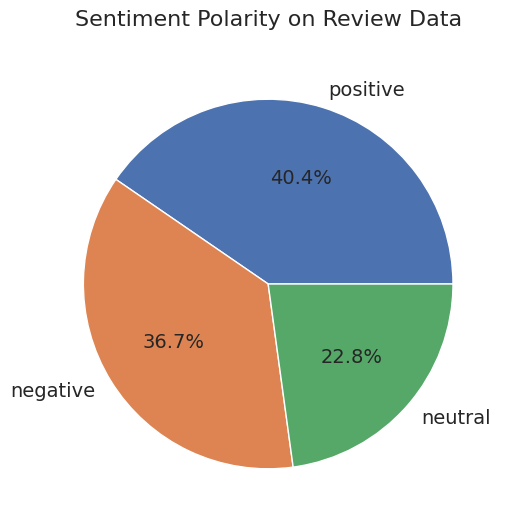

In [23]:
sizes = [count for count in clean_df['polarity'].value_counts()]
labels = list(clean_df['polarity'].value_counts().index)

fig, ax = plt.subplots(figsize=(6, 6))
ax.pie(x=sizes, labels=labels, autopct='%1.1f%%', textprops={'fontsize': 14})
ax.set_title('Sentiment Polarity on Review Data', fontsize=16, pad=20)
plt.show()

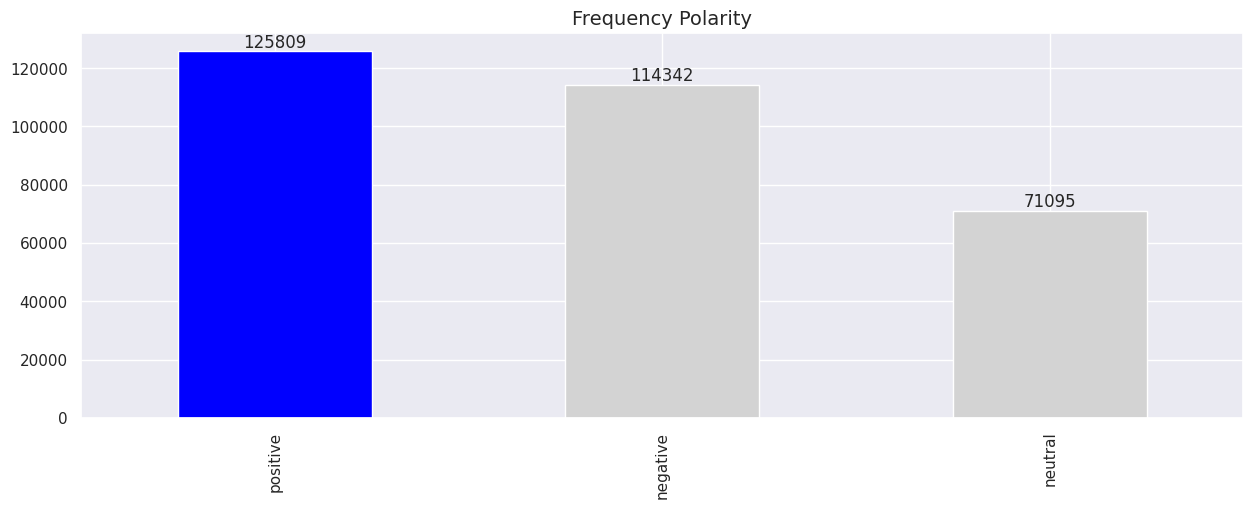

In [24]:
plot_frequency_data_kualitatif(clean_df, "polarity", "Frequency Polarity")

In [25]:
positive_review = prep_word_cloud("positive")
positive_review

,text_final,score,polarity,text_stopword
1,enak promo,5,positive,"[enak, promo]"
2,mantap,5,positive,[mantap]
3,th berlangganan gojekaku pakai gojek berbergia...,5,positive,"[th, berlangganan, gojekaku, pakai, gojek, ber..."
4,top,5,positive,[top]
5,nice,5,positive,[nice]
...,...,...,...,...
125805,pesan makanan jam tlol,1,positive,"[pesan, makanan, jam, tlol]"
125806,gojek penjemputan gofood lambat terlambat,1,positive,"[gojek, penjemputan, gofood, lambat, terlambat]"
125807,tolong management gojek denda kasih sehari den...,1,positive,"[tolong, management, gojek, denda, kasih, seha..."
125808,lambat jaringan oke,1,positive,"[lambat, jaringan, oke]"


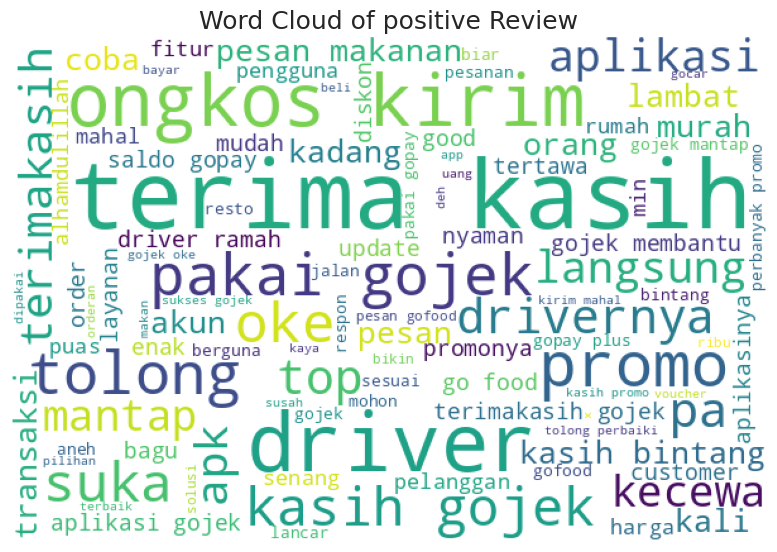

In [26]:
plot_word_cloud(positive_review["text_stopword"], "positive")

In [27]:
negative_review = prep_word_cloud("negative")
negative_review

,text_final,score,polarity,text_stopword
1,gojek ngebantu aktivitas seharihari pesan ojek...,5,negative,"[gojek, ngebantu, aktivitas, seharihari, pesan..."
2,samapi pelayanannya bagus,5,negative,"[samapi, pelayanannya, bagus]"
3,gojek mayan repot,5,negative,"[gojek, mayan, repot]"
4,bagus,5,negative,[bagus]
5,bagus,5,negative,[bagus]
...,...,...,...,...
114338,pesan makanan daftar kesalahan nunggu jam tung...,1,negative,"[pesan, makanan, daftar, kesalahan, nunggu, ja..."
114339,jelek iklannya ganggu orang main game pencet x...,1,negative,"[jelek, iklannya, ganggu, orang, main, game, p..."
114340,males kesal gojek ribet masuk akun gojekku lup...,1,negative,"[males, kesal, gojek, ribet, masuk, akun, goje..."
114341,aplikasi payah,1,negative,"[aplikasi, payah]"


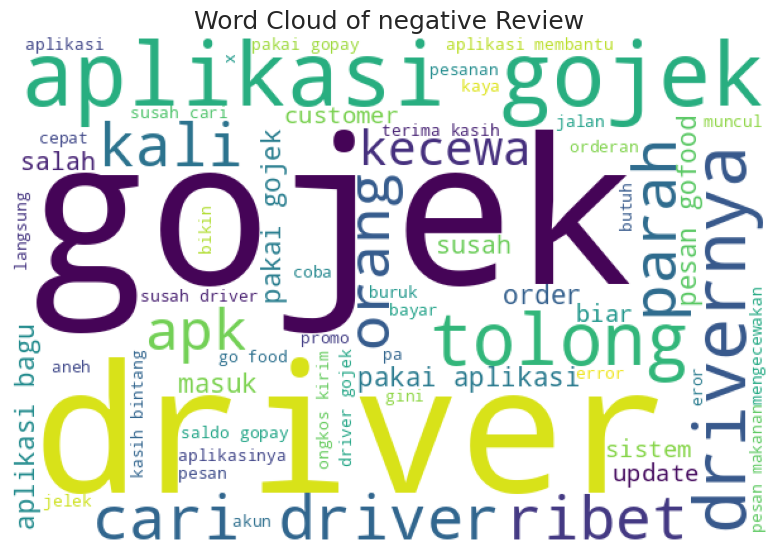

In [28]:
plot_word_cloud(negative_review["text_stopword"], "negative")

In [29]:
neutral_review = prep_word_cloud("neutral")
neutral_review

,text_final,score,polarity,text_stopword
1,keren,5,neutral,[keren]
2,membantu sehari disaat membutuhkan,5,neutral,"[membantu, sehari, disaat, membutuhkan]"
3,okey,5,neutral,[okey]
4,tingkatkan,5,neutral,[tingkatkan]
5,sak jos elektronik,5,neutral,"[sak, jos, elektronik]"
...,...,...,...,...
71091,goride adapercuma pakai gojek goride,1,neutral,"[goride, adapercuma, pakai, gojek, goride]"
71092,order gocar kali dicancel driver,1,neutral,"[order, gocar, kali, dicancel, driver]"
71093,gopay cicil hentikan nawarin pinjol gopay apaaan,1,neutral,"[gopay, cicil, hentikan, nawarin, pinjol, gopa..."
71094,habis instal ulang loading dipakai,1,neutral,"[habis, instal, ulang, loading, dipakai]"


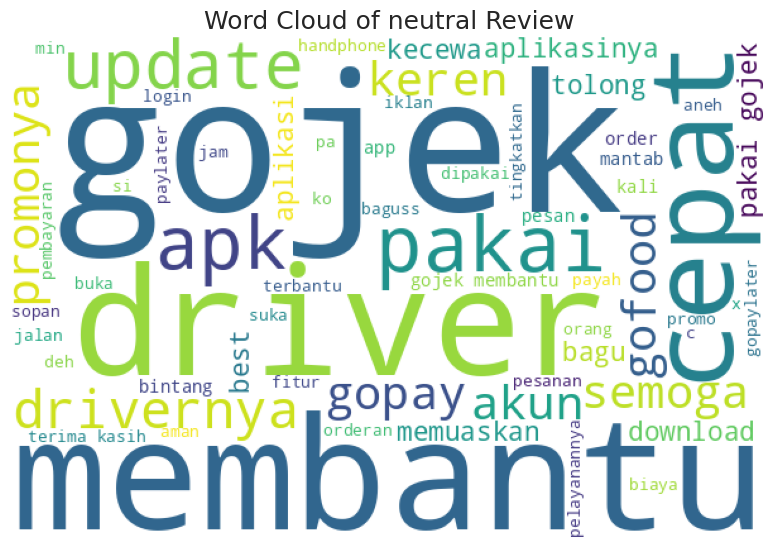

In [30]:
plot_word_cloud(neutral_review["text_stopword"], "neutral")

In [31]:
clean_df

,content,score,text_clean,text_casefoldingText,text_slangwords,text_tokenizingText,text_stopword,text_final,polarity_score,polarity
0,mantap,5,mantap,mantap,mantap,[mantap],[mantap],mantap,5,positive
1,dari th 2019 sampai 2026 aku masih berlanggana...,5,dari th sampai aku masih berlangganan gojeka...,dari th sampai aku masih berlangganan gojeka...,dari th sampai saya masih berlangganan gojekak...,"[dari, th, sampai, saya, masih, berlangganan, ...","[th, berlangganan, gojekaku, pakai, gojek, ber...",th berlangganan gojekaku pakai gojek berbergia...,7,positive
2,top,5,top,top,top,[top],[top],top,5,positive
3,sangat buruk 🤮,1,sangat buruk,sangat buruk,sangat buruk,"[sangat, buruk]",[buruk],buruk,-5,negative
4,nice,5,nice,nice,nice,[nice],[nice],nice,4,positive
...,...,...,...,...,...,...,...,...,...,...
499990,Sangat membantu sehari hari disaat membutuhkan.,5,Sangat membantu sehari hari disaat membutuhkan,sangat membantu sehari hari disaat membutuhkan,sangat membantu sehari hari disaat membutuhkan,"[sangat, membantu, sehari, hari, disaat, membu...","[membantu, sehari, disaat, membutuhkan]",membantu sehari disaat membutuhkan,0,neutral
499991,Ga ada gojek mayan repot kita,5,Ga ada gojek mayan repot kita,ga ada gojek mayan repot kita,tidak ada gojek mayan repot kita,"[tidak, ada, gojek, mayan, repot, kita]","[gojek, mayan, repot]",gojek mayan repot,-5,negative
499995,Enak banyak promo nya,5,Enak banyak promo nya,enak banyak promo nya,enak banyak promo nya,"[enak, banyak, promo, nya]","[enak, promo]",enak promo,4,positive
499996,Permasalahannya yaitu Kenapa SMS OTP SELALU LA...,1,Permasalahannya yaitu Kenapa SMS OTP SELALU LA...,permasalahannya yaitu kenapa sms otp selalu la...,permasalahannya yaitu kenapa sms otp selalu la...,"[permasalahannya, yaitu, kenapa, sms, otp, sel...","[permasalahannya, sms, otp, gara, gara, ulang,...",permasalahannya sms otp gara gara ulang kali a...,-11,negative


In [32]:
le = LabelEncoder()
clean_df["polarity"] = le.fit_transform(clean_df["polarity"])
clean_df

,content,score,text_clean,text_casefoldingText,text_slangwords,text_tokenizingText,text_stopword,text_final,polarity_score,polarity
0,mantap,5,mantap,mantap,mantap,[mantap],[mantap],mantap,5,2
1,dari th 2019 sampai 2026 aku masih berlanggana...,5,dari th sampai aku masih berlangganan gojeka...,dari th sampai aku masih berlangganan gojeka...,dari th sampai saya masih berlangganan gojekak...,"[dari, th, sampai, saya, masih, berlangganan, ...","[th, berlangganan, gojekaku, pakai, gojek, ber...",th berlangganan gojekaku pakai gojek berbergia...,7,2
2,top,5,top,top,top,[top],[top],top,5,2
3,sangat buruk 🤮,1,sangat buruk,sangat buruk,sangat buruk,"[sangat, buruk]",[buruk],buruk,-5,0
4,nice,5,nice,nice,nice,[nice],[nice],nice,4,2
...,...,...,...,...,...,...,...,...,...,...
499990,Sangat membantu sehari hari disaat membutuhkan.,5,Sangat membantu sehari hari disaat membutuhkan,sangat membantu sehari hari disaat membutuhkan,sangat membantu sehari hari disaat membutuhkan,"[sangat, membantu, sehari, hari, disaat, membu...","[membantu, sehari, disaat, membutuhkan]",membantu sehari disaat membutuhkan,0,1
499991,Ga ada gojek mayan repot kita,5,Ga ada gojek mayan repot kita,ga ada gojek mayan repot kita,tidak ada gojek mayan repot kita,"[tidak, ada, gojek, mayan, repot, kita]","[gojek, mayan, repot]",gojek mayan repot,-5,0
499995,Enak banyak promo nya,5,Enak banyak promo nya,enak banyak promo nya,enak banyak promo nya,"[enak, banyak, promo, nya]","[enak, promo]",enak promo,4,2
499996,Permasalahannya yaitu Kenapa SMS OTP SELALU LA...,1,Permasalahannya yaitu Kenapa SMS OTP SELALU LA...,permasalahannya yaitu kenapa sms otp selalu la...,permasalahannya yaitu kenapa sms otp selalu la...,"[permasalahannya, yaitu, kenapa, sms, otp, sel...","[permasalahannya, sms, otp, gara, gara, ulang,...",permasalahannya sms otp gara gara ulang kali a...,-11,0


In [33]:
X = clean_df["text_final"]
y = clean_df["polarity"]

# Feature Extraction

In [40]:
tfidf = TfidfVectorizer(ngram_range=(1,2), max_features=600, min_df=20, max_df=0.9)
X_tfidf_rf = tfidf.fit_transform(X)
features_df = pd.DataFrame(X_tfidf_rf.toarray(), columns=tfidf.get_feature_names_out())
features_df

,abang,admin,aduh,akal,akses,aktif,aktifitas,aktivitas,akun,akun gojek,...,urusan,verifikasi,versi,via,vocer,vocher,voucher,wajar,wifi,yah
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
311241,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
311242,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
311243,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
311244,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.232595,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [41]:
tfidf = TfidfVectorizer(ngram_range=(1,2), max_features=600, min_df=20, max_df=0.9)
X_tfidf_xgb = tfidf.fit_transform(X)
features_df = pd.DataFrame(X_tfidf_xgb.toarray(), columns=tfidf.get_feature_names_out())
features_df

,abang,admin,aduh,akal,akses,aktif,aktifitas,aktivitas,akun,akun gojek,...,urusan,verifikasi,versi,via,vocer,vocher,voucher,wajar,wifi,yah
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
311241,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
311242,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
311243,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
311244,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.232595,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [42]:
tfidf = TfidfVectorizer(ngram_range=(1,2), max_features=600, min_df=20, max_df=0.9)
X_tfidf_ = tfidf.fit_transform(X)
features_df = pd.DataFrame(X_tfidf_xgb.toarray(), columns=tfidf.get_feature_names_out())
features_df

,abang,admin,aduh,akal,akses,aktif,aktifitas,aktivitas,akun,akun gojek,...,urusan,verifikasi,versi,via,vocer,vocher,voucher,wajar,wifi,yah
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
311241,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
311242,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
311243,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
311244,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.232595,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


# Data Splitter

In [48]:
X_train_rf_idf, X_test_rf_idf, y_train_rf_idf, y_test_rf_idf = train_test_split(X_tfidf_rf.toarray(), y, test_size=0.2, random_state=seed, stratify=y)
X_train_rf_idf.shape, X_test_rf_idf.shape

((248996, 600), (62250, 600))

In [49]:
X_train_xgb, X_test_xgb, y_train_xgb, y_test_xgb = train_test_split(X_tfidf_xgb.toarray(), y, test_size=0.3, random_state=seed, stratify=y)
X_train_xgb.shape, X_test_xgb.shape

((217872, 600), (93374, 600))

In [51]:
X_train_dl, X_test_dl, y_train_dl, y_test_dl = train_test_split(X, y, test_size=0.2, random_state=seed, stratify=y)
X_train_dl.shape, X_test_dl.shape

((248996,), (62250,))

# Modeling & Evaluation

In [44]:
model_rf_idf = RandomForestClassifier(random_state=seed)
model_rf_idf.fit(X_train_rf_idf, y_train_rf_idf)

y_pred_train_rf_idf = model_rf_idf.predict(X_train_rf_idf)
y_pred_test_rf_idf = model_rf_idf.predict(X_test_rf_idf)

accuracy_train_rf_idf = accuracy_score(y_pred_train_rf_idf, y_train_rf_idf)
accuracy_test_rf_idf = accuracy_score(y_pred_test_rf_idf, y_test_rf_idf)

print('Random Forest TF-IDF - accuracy_train:', accuracy_train_rf_idf)
print('Random Forest TF-IDF - accuracy_test:', accuracy_test_rf_idf)

Random Forest TF-IDF - accuracy_train: 0.960176067085415
Random Forest TF-IDF - accuracy_test: 0.8619919678714859


In [45]:
model_xgb = xgb.XGBClassifier(
    n_estimators=300,
    learning_rate=0.1,
    max_depth=9,
    objective='multi:softprob',
    random_state=seed
)
model_xgb.fit(X_train_xgb, y_train_xgb)

y_pred_train_xgb = model_xgb.predict(X_train_xgb)
y_pred_test_xgb = model_xgb.predict(X_test_xgb)

accuracy_train_xgb = accuracy_score(y_pred_train_xgb, y_train_xgb)
accuracy_test_xgb = accuracy_score(y_pred_test_xgb, y_test_xgb)

print('XGB - accuracy_train:', accuracy_train_xgb)
print('XGB - accuracy_test:', accuracy_test_xgb)

XGB - accuracy_train: 0.8921476830432548
XGB - accuracy_test: 0.8715059866772334


In [ ]:
class TargetAccuracyCallback(TrainerCallback):
    def on_evaluate(self, args, state, control, metrics, **kwargs):
        val_acc = metrics.get('eval_accuracy', 0)
        if val_acc >= 0.92:
            print(f"\nTarget tercapai! Akurasi validasi menyentuh {val_acc * 100:.2f}%")
            control.should_training_stop = True 

In [48]:
class SentimentDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = list(labels)

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item

    def __len__(self):
        return len(self.labels)

In [49]:
def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)
    acc = accuracy_score(labels, preds)
    return {'accuracy': acc}

In [50]:
num_classes = 3
max_length = 32
model_name = "indobenchmark/indobert-base-p1"

In [51]:
tokenizer = AutoTokenizer.from_pretrained(model_name)
model_dl = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=num_classes)
model_dl

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/498M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: indobenchmark/indobert-base-p1
Key               | Status  | 
------------------+---------+-
classifier.weight | MISSING | 
classifier.bias   | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


model.safetensors:   0%|          | 0.00/498M [00:00<?, ?B/s]

BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(50000, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12,

In [52]:
train_encodings = tokenizer(X_train_dl.tolist(), truncation=True, padding=True, max_length=32)
test_encodings = tokenizer(X_test_dl.tolist(), truncation=True, padding=True, max_length=32)

In [53]:
train_dataset = SentimentDataset(train_encodings, y_train_dl)
test_dataset = SentimentDataset(test_encodings, y_test_dl)
train_dataset

In [54]:
training_args = TrainingArguments(
    output_dir='./results_indobert',
    num_train_epochs=2,             
    learning_rate=1e-6,            
    eval_strategy="epoch",           
    save_strategy="epoch",     
    logging_dir='./logs',
    load_best_model_at_end=True,
    metric_for_best_model="accuracy"
)

trainer = Trainer(
    model=model_dl,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics,
    callbacks=[TargetAccuracyCallback()]
)

# trainer.train(resume_from_checkpoint=True)
trainer.train()

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.
/usr/local/lib/python3.12/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


Epoch,Training Loss,Validation Loss,Accuracy
1,0.594062,0.508198,0.912016
2,0.492199,0.450062,0.925526



Target tercapai! Akurasi validasi menyentuh 92.55%


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

TrainOutput(global_step=31126, training_loss=0.6517403554864295, metrics={'train_runtime': 5920.0925, 'train_samples_per_second': 84.119, 'train_steps_per_second': 5.258, 'total_flos': 8189273570075136.0, 'train_loss': 0.6517403554864295, 'epoch': 2.0})

In [55]:
acc_train = trainer.evaluate(eval_dataset=trainer.train_dataset)
acc_val = trainer.evaluate(eval_dataset=trainer.eval_dataset)

print(f"Akurasi Training: {acc_train['eval_accuracy']}")
print(f"Akurasi Testing: {acc_val['eval_accuracy']}")

/usr/local/lib/python3.12/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(



Target tercapai! Akurasi validasi menyentuh 93.00%


/usr/local/lib/python3.12/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(



Target tercapai! Akurasi validasi menyentuh 92.55%
Akurasi Training: 0.929958714196212
Akurasi Testing: 0.9255261044176707


In [56]:
clean_df["polarity"].value_counts()

polarity
2    125809
0    114342
1     71095
Name: count, dtype: int64

In [57]:
pd.Series(le.inverse_transform(clean_df["polarity"])).value_counts()

positive    125809
negative    114342
neutral      71095
Name: count, dtype: int64

In [60]:
new_sentences = ["barang ini sangat mengecewakan dan rusak", "kualitasnya luar biasa saya sangat suka"]
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
inputs = tokenizer(new_sentences, padding=True, truncation=True, max_length=32, return_tensors="pt").to(device)
model_dl.to(device)

with torch.no_grad():
    outputs = model_dl(**inputs)
    logits = outputs.logits
    probabilities = torch.nn.functional.softmax(logits, dim=-1)
    predictions = torch.argmax(probabilities, dim=1).cpu().numpy()

label_map = {0: "Negatif", 1: "Netral", 2: "Positif"}

for i, text in enumerate(new_sentences):
    predictions_class = predictions[i]
    confidence = probabilities[i][predictions_class].item() * 100
    print(f"Teks: '{text}'")
    print(f"Kalimat: {label_map[predictions_class]} (Confidence: {confidence:.2f}%)")
    print("-" * 30)

Teks: 'barang ini sangat mengecewakan dan rusak'
Kalimat: Negatif (Confidence: 98.57%)
------------------------------
Teks: 'kualitasnya luar biasa saya sangat suka'
Kalimat: Positif (Confidence: 99.19%)
------------------------------


In [3]:
!pip freeze > requirements.txt